In [1]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [2]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown
!pip -q install pylhe

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/develop/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 7.2 MB/s eta 0:00:00


In [ ]:

!pip -q install pylhe
import helpers as hp
importlib.reload(hp)

<module 'helpers' from '/content/helpers.py'>

In [ ]:
# ************************************************************
# Grab a coffe, this might take some time! (~17 min)
# ************************************************************

# ============================================================
# Execute Data Extraction
# ============================================================

# Standard Model (LO)
df_sm = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/SM/*.lhe.gz',
    label='SM',
    is_nlo=False
)

# VLF (NLO)
df_vlf = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/VLF/*.lhe.gz',
    label='VLF',
    is_nlo=True
)

# Scalar (NLO)
df_scalar = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/Scalar/*.lhe.gz',
    label='Scalar',
    is_nlo=True
)

# Zprime (LO)
df_zp = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/Zprime/*.lhe.gz',
    label='Zprime',
    is_nlo=False,
)

# Fake Data (NLO)
df_fake = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/FakeData/*.lhe.gz',
    label='FakeData',
    is_nlo=True
)

# Consolidate BSM models into a single DataFrame
df_bsm = pd.concat([df_vlf, df_scalar, df_zp, df_fake], ignore_index=True)

print("\n--- Direct LHE Extraction Complete ---")
print(f"SM Events Loaded:  {len(df_sm)}")
print(f"BSM Events Loaded: {len(df_bsm)}\n")

Loading SM from 1 LHE files...


Reading events.lhe.gz: 0it [00:00, ?it/s]

Loading VLF from 1 LHE files...
  -> [BIAS DETECTED] VLF: Rescaled weights by 2.74885 (True: 1.26500e+00 pb, LHE: 4.60193e-01 pb)


Reading events.lhe.gz: 0it [00:00, ?it/s]

Loading Scalar from 1 LHE files...
  -> [BIAS DETECTED] Scalar: Rescaled weights by 0.22481 (True: 1.26900e+00 pb, LHE: 5.64478e+00 pb)


...

Loading Zprime from 1 LHE files...


Reading unweighted_events.lhe.gz: 0it [00:00, ?it/s]

Loading FakeData from 1 LHE files...
  -> [BIAS DETECTED] FakeData: Rescaled weights by 0.22481 (True: 1.26900e+00 pb, LHE: 5.64478e+00 pb)


Reading events.lhe.gz: 0it [00:00, ?it/s]


--- Direct LHE Extraction Complete ---
SM Events Loaded:  2592664
BSM Events Loaded: 9200027



In [3]:
# ------------------------------------------------------------
# Automated Configuration (Using Best Fits)
# ------------------------------------------------------------
best_fits = {
    'VLF':    {'mPsiT': 1400., 'mSDM': 1300., 'scale_factor': 1.0},
    'Scalar': {'mST': 1000., 'mChi': 900., 'scale_factor': 1.0},
    'Zprime': {'mZp': 2800.,                'scale_factor': 1.0},
    'Zprime_20pc': {'mZp': 2600.,           'scale_factor': 1.0},
    'FakeData': {'scale_factor': 1.0}
}

#sm_files = list(glob.glob('./drive/MyDrive/Full_Distributions/sm/mPsiT_0_mSDM_0.npz')) #./drive/MyDrive/Distributions/SM/pp2ttbar/bias_article*/*.npz
#sm_files = list(glob.glob('./drive/MyDrive/Full_Distributions/sm/mZp_0.npz'))
sm_files = list(glob.glob('./drive/MyDrive/Distributions/SM/pp2ttbar_z_prime/*/mZp_0.npz'))

#sm_files = list(glob.glob('./drive/MyDrive/Distributions/SM/pp2ttbar/bias_article*/*.npz')) #./drive/MyDrive/Distributions/SM/pp2ttbar/bias_article*/*.npz

fake_data_files = list(glob.glob('./drive/MyDrive/Full_Distributions/FakeData/*/mPsiT_1000_mSDM_900.npz'))

vlf_files = (
    list(glob.glob(f'./drive/MyDrive/Full_Distributions/VLF/*/mPsiT_1400_mSDM_1300.npz'))
)

scalar_files = (
    list(glob.glob(f'./drive/MyDrive/Full_Distributions/Scalar/*/mPsiT_1000_mSDM_900.npz'))
)

#zp_files = list(glob.glob(f'./drive/MyDrive/Full_Distributions/Zprime/mZp_2800.npz'))
zp_files = list(glob.glob(f'./drive/MyDrive/Distributions/Zprime/Batches_2800/*/mZp_2800.npz'))
zp_20pc_files = list(glob.glob(f'./drive/MyDrive/Full_Distributions/Zprime_20pcW/mZp_2600.npz'))

print("\n--- Model Assembly Check ---")
print(f"VLF files loaded:         {len(vlf_files)}")
print(f"Scalar files loaded:      {len(scalar_files)}")
print(f"Zprime files loaded:      {len(zp_files)}")
print(f"Zprime_20pc files loaded: {len(zp_20pc_files)}")
print(f"Fake data files found:    {len(fake_data_files)}")
print(f"SM files found:           {len(sm_files)}\n")

# ------------------------------------------------------------
# Memory-Optimized Extraction Setup
# ------------------------------------------------------------
KEYS_TO_SUM = ['xsec (pb)', 'n_events']
KEYS_TO_KEEP = ['mTT', 'weights']

raw_data = {
    'FakeData':    {'arrays': {}, 'scalars': {}},
    'Scalar':      {'arrays': {}, 'scalars': {}},
    'VLF':         {'arrays': {}, 'scalars': {}},
    'Zprime':      {'arrays': {}, 'scalars': {}},
    'Zprime_20pc': {'arrays': {}, 'scalars': {}},
    'SM':          {'arrays': {}, 'scalars': {}}
}

# ------------------------------------------------------------
# Data Loading Loop
# ------------------------------------------------------------
all_files = list(set(vlf_files + scalar_files + zp_files + zp_20pc_files + sm_files + fake_data_files))

for f in all_files:
    aux = np.load(f, allow_pickle=True)
    print(aux['model'], aux['nevents'])
    if f in sm_files:
        model_name = 'SM'
    else:
        model_name = aux['model']

    if isinstance(model_name, np.ndarray):
        model_name = model_name.item() if model_name.size == 1 else model_name[0]
    if isinstance(model_name, bytes):
        model_name = model_name.decode('utf-8')

    targets = []

    if f in fake_data_files:
        targets.append(raw_data['FakeData'])

    if (model_name == '1-loop VLF' or model_name == 'VLF') and f in vlf_files:
        targets.append(raw_data['VLF'])
    elif (model_name == '1-loop Scalar' or model_name == 'Scalar') and f in scalar_files:
        targets.append(raw_data['Scalar'])
    elif model_name == 'Z prime' and f in zp_files:
        targets.append(raw_data['Zprime'])
    elif model_name == 'Z prime' and f in zp_20pc_files:
        targets.append(raw_data['Zprime_20pc'])
    elif model_name == 'SM' and f in sm_files:
        targets.append(raw_data['SM'])

    if not targets:
        aux.close()
        continue

    for target in targets:
        for key in aux.files:
            val = aux[key]
            if key in KEYS_TO_SUM:
                if key not in target['scalars']: target['scalars'][key] = 0.0
                target['scalars'][key] += float(val.item())
            elif val.ndim == 0 or val.size == 1:
                if not isinstance(val.item(), dict):
                    target['scalars'][key] = val.item()
            else:
                if key not in KEYS_TO_KEEP: continue
                if key not in target['arrays']: target['arrays'][key] = []
                target['arrays'][key].append(val[:])

    aux.close()

# Concatenate arrays
for model in raw_data:
    for key, list_of_arrays in raw_data[model]['arrays'].items():
        if list_of_arrays:
            raw_data[model]['arrays'][key] = np.concatenate(list_of_arrays, axis=0)

# ------------------------------------------------------------
# Post-Processing: Weights & Explicit High-Precision Normalization
# ------------------------------------------------------------
# Map each model to the number of files loaded
file_counts = {
    'FakeData':    len(fake_data_files),
    'Scalar':      len(scalar_files),
    'VLF':         len(vlf_files),
    'Zprime':      len(zp_files),
    'Zprime_20pc': len(zp_20pc_files),
    'SM':          len(sm_files)
}

for model_name, data in raw_data.items():
    arrs = data['arrays']
    if not arrs: continue

    # 1. Cast arrays to strict float64 immediately
    if 'weights' in arrs:
        arrs['weights'] = arrs['weights'].astype(np.float64)

        # Apply the division logic to ALL models based on file count
        num_files = file_counts.get(model_name, 1)
        if num_files > 0:
            arrs['weights'] /= num_files
            print(f"[{model_name:11}] Weights averaged over {num_files} file(s).")

    # 2. Scale Fake Data
    if model_name == 'FakeData' and 'weights' in arrs:
        factor = np.float64(best_fits.get(model_name, {}).get('scale_factor', 1.0))
        factor_sq = factor ** 2
        arrs['weights'] = arrs['weights'] * factor_sq
        if factor_sq != 1.0:
            print(f"[{model_name:11}] Explicitly Scaled by {factor:.6e} to hit target.")

    # 3. Scale BSM models
    elif model_name in ['VLF', 'Scalar', 'Zprime', 'Zprime_20pc']:
        factor = np.float64(best_fits.get(model_name, {}).get('scale_factor', 1.0))
        factor_sq = factor ** 2
        if factor_sq != 1.0 and 'weights' in arrs:
            arrs['weights'] = arrs['weights'] * factor_sq
            print(f"[{model_name:11}] Scaled by Best-Fit factor: {factor:.6e}")

    # Rename securely
    if 'weights' in arrs: arrs['weight'] = arrs.pop('weights')
    if 'mTT' in arrs:     arrs['m_tt'] = arrs.pop('mTT')

# ------------------------------------------------------------
# Pure NumPy Assembly into DataFrames
# ------------------------------------------------------------
l_fake = len(raw_data['FakeData']['arrays'].get('weight', []))
l_s    = len(raw_data['Scalar']['arrays'].get('weight', []))
l_v    = len(raw_data['VLF']['arrays'].get('weight', []))
l_z    = len(raw_data['Zprime']['arrays'].get('weight', []))
l_z20  = len(raw_data['Zprime_20pc']['arrays'].get('weight', []))

final_dict = {}
labels_list = []
if l_fake > 0: labels_list.append(np.full(l_fake, 'FakeData'))
if l_s > 0:    labels_list.append(np.full(l_s, 'Scalar'))
if l_v > 0:    labels_list.append(np.full(l_v, 'VLF'))
if l_z > 0:    labels_list.append(np.full(l_z, 'Zprime'))
if l_z20 > 0:  labels_list.append(np.full(l_z20, 'Zprime_20pc'))

if labels_list:
    final_dict['label'] = np.concatenate(labels_list)

keys_to_stack = list(raw_data['SM']['arrays'].keys())

for key in keys_to_stack:
    arrs_to_concat = []
    if l_fake > 0 and key in raw_data['FakeData']['arrays']:    arrs_to_concat.append(raw_data['FakeData']['arrays'][key])
    if l_s > 0 and key in raw_data['Scalar']['arrays']:         arrs_to_concat.append(raw_data['Scalar']['arrays'][key])
    if l_v > 0 and key in raw_data['VLF']['arrays']:            arrs_to_concat.append(raw_data['VLF']['arrays'][key])
    if l_z > 0 and key in raw_data['Zprime']['arrays']:         arrs_to_concat.append(raw_data['Zprime']['arrays'][key])
    if l_z20 > 0 and key in raw_data['Zprime_20pc']['arrays']:  arrs_to_concat.append(raw_data['Zprime_20pc']['arrays'][key])

    if arrs_to_concat:
        final_dict[key] = np.concatenate(arrs_to_concat, axis=0)

df_bsm = pd.DataFrame(final_dict)

df_sm = pd.DataFrame(raw_data['SM']['arrays'])
if not df_sm.empty:
    df_sm['label'] = 'SM'

del raw_data, final_dict, labels_list
gc.collect()

print("\n--- DataFrame Assembly Complete ---")
print(f"BSM Events: {len(df_bsm)}")
print(f"SM Events:  {len(df_sm)}")


--- Model Assembly Check ---
VLF files loaded:         2
Scalar files loaded:      2
Zprime files loaded:      5
Zprime_20pc files loaded: 1
Fake data files found:    2
SM files found:           5

Z prime 1000000
Z prime 1000000
Scalar 2617952
Scalar 2617952
Z prime 1000000
Z prime 1000000
Z prime 1000000
Z prime 1000000
Z prime 1000000
VLF 2969907
Z prime 1000000
Scalar 2602323
Z prime 1000000
Scalar 2602323
Z prime 1000000
VLF 2995381
Z prime 1000000
[FakeData   ] Weights averaged over 2 file(s).
[Scalar     ] Weights averaged over 2 file(s).
[VLF        ] Weights averaged over 2 file(s).
[Zprime     ] Weights averaged over 5 file(s).
[Zprime_20pc] Weights averaged over 1 file(s).
[SM         ] Weights averaged over 5 file(s).

--- DataFrame Assembly Complete ---
BSM Events: 22405838
SM Events:  5000000


Integrating tail from m_tt >= 1500.0 GeV
--------------------------------------------------
TEST 1: RAW YIELDS (Include SM Background)
SM:           1.2617 +- 0.0020
VLF NLO:      1.2643 +- 0.0012
Scalar NLO:   1.2683 +- 0.0015
Z prime (1%): 1.2617 +- 0.0017
Z prime (20%):1.2567 +- 0.0038
Fake Data:    1.2683 +- 0.0015
yDM_S:        9.98424e-01
mu_Z:         1.00106e+00

TEST 2: PURE SIGNAL (Background Subtracted)
VLF NLO:      0.0026 +- 0.0023
Scalar NLO:   0.0066 +- 0.0025
Z prime (1%): -0.0001 +- 0.0026
Z prime (20%):-0.0050 +- 0.0043
Fake Data:    0.0066 +- 0.0025
yDM_S:        6.28546e-01
mu_Z:         nan


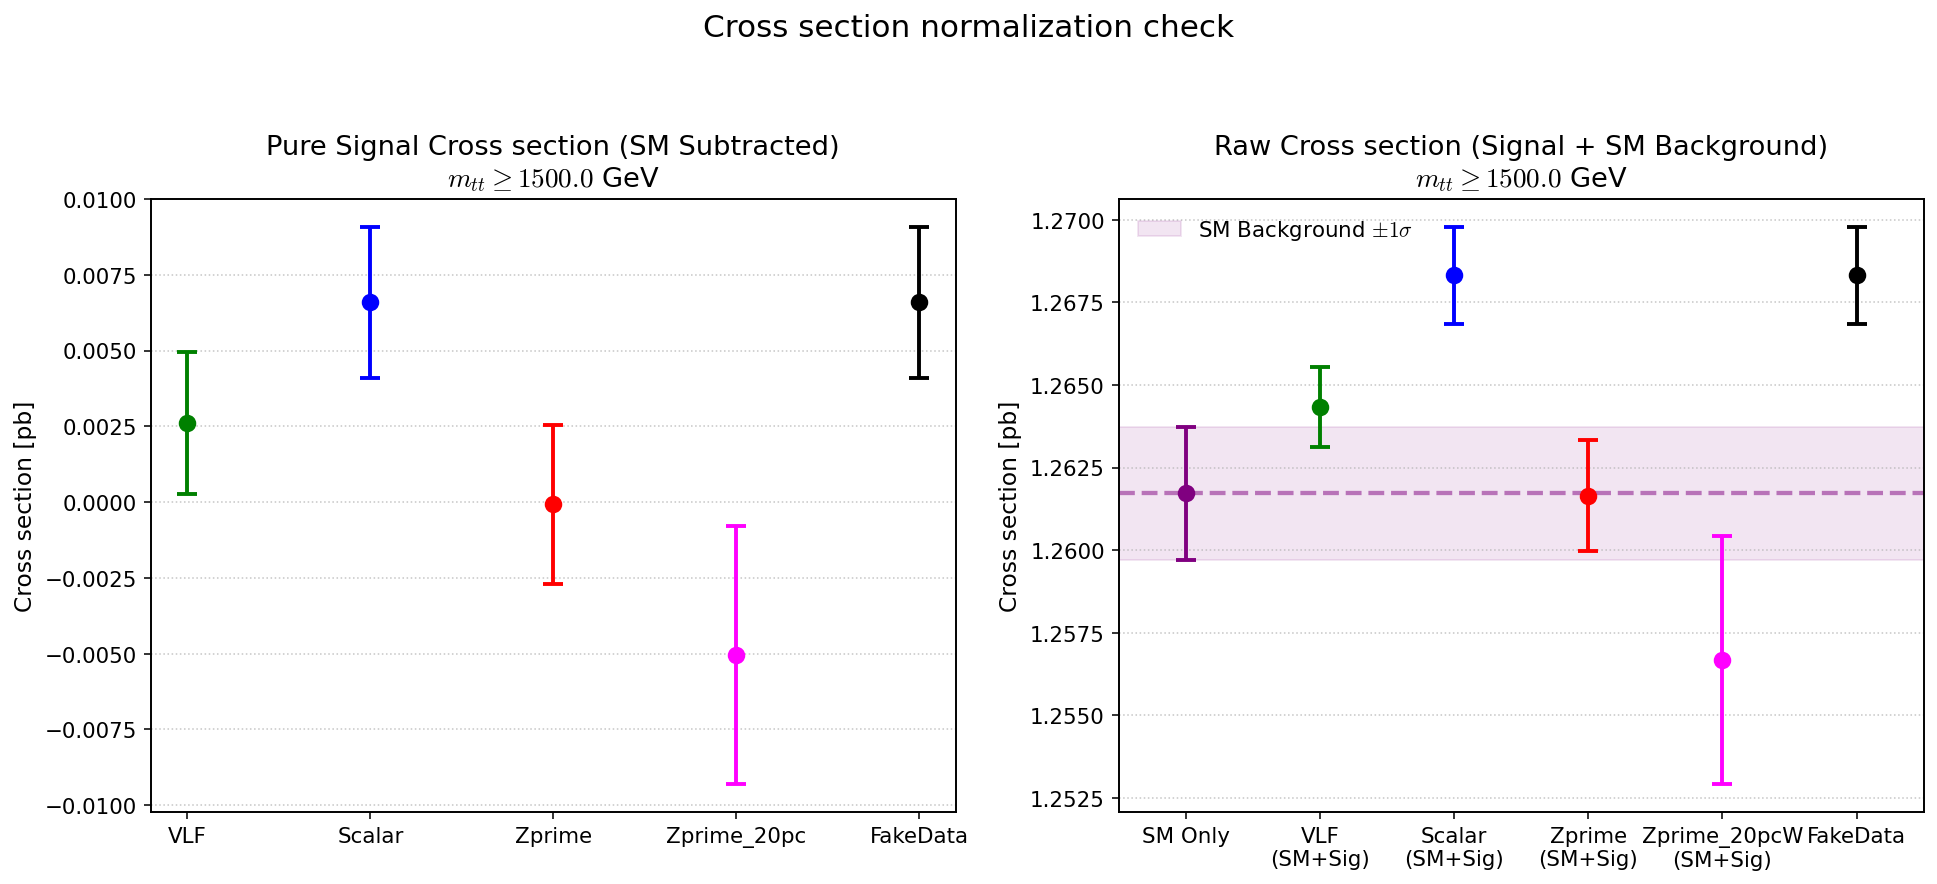

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Histogram Generation (Applying Luminosity)
# ------------------------------------------------------------
lum = 500.0
# Using the same binning as your plotting script
bins = np.linspace(1500, 4500, 60 + 1)

# Generate SM Histogram
w_sm = df_sm['weight'].values
h_sm, _ = np.histogram(df_sm['m_tt'], bins=bins, weights=w_sm)
hErr_sm, _ = np.histogram(df_sm['m_tt'], bins=bins, weights=w_sm**2)

# Generate BSM Histograms in the exact order required: [VLF, Scalar, Zprime, Zprime_20pc, FakeData]
bsm_hists = []
bms_histsErr = []
for model in ['VLF', 'Scalar', 'Zprime', 'Zprime_20pc', 'FakeData']:
    df_model = df_bsm[df_bsm['label'] == model]
    w_model = df_model['weight'].values
    h_model, _ = np.histogram(df_model['m_tt'], bins=bins, weights=w_model)
    hErr_model, _ = np.histogram(df_model['m_tt'], bins=bins, weights=w_model**2)
    bsm_hists.append(h_model)
    bms_histsErr.append(hErr_model)

# ------------------------------------------------------------
# 2. Setup Variables for the Tests
# ------------------------------------------------------------
mPsiT = 1000.0  # From your best_fits dictionary
mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start

print(f"Integrating tail from m_tt >= {mTT_start} GeV")
print("-" * 50)

# ------------------------------------------------------------
# TEST 1: Total Raw Yields (Signal + Background)
# ------------------------------------------------------------
tail_sum_SM  = np.sum(h_sm[tail_mask])
tail_sum_SM_Err = np.sqrt(np.sum(hErr_sm[tail_mask]))

tail_sum_NLO = np.sum(bsm_hists[0][tail_mask])
tail_sum_NLO_Err = np.sqrt(np.sum(bms_histsErr[0][tail_mask]))

tail_sum_S   = np.sum(bsm_hists[1][tail_mask])
tail_sum_S_Err = np.sqrt(np.sum(bms_histsErr[1][tail_mask]))

tail_sum_Zp  = np.sum(bsm_hists[2][tail_mask])
tail_sum_Zp_Err = np.sqrt(np.sum(bms_histsErr[2][tail_mask]))

tail_sum_Zp20pc = np.sum(bsm_hists[3][tail_mask])
tail_sum_Zp20pc_Err = np.sqrt(np.sum(bms_histsErr[3][tail_mask]))

# Extracting Fake Data (Shifted to Index 4)
tail_sum_Fake = np.sum(bsm_hists[4][tail_mask])
tail_sum_Fake_Err = np.sqrt(np.sum(bms_histsErr[4][tail_mask]))

yDM_S = np.sqrt(tail_sum_NLO / tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO / tail_sum_Zp)

print("TEST 1: RAW YIELDS (Include SM Background)")
print(f"SM:           {tail_sum_SM:.4f} +- {tail_sum_SM_Err:.4f}")
print(f"VLF NLO:      {tail_sum_NLO:.4f} +- {tail_sum_NLO_Err:.4f}")
print(f"Scalar NLO:   {tail_sum_S:.4f} +- {tail_sum_S_Err:.4f}")
print(f"Z prime (1%): {tail_sum_Zp:.4f} +- {tail_sum_Zp_Err:.4f}")
print(f"Z prime (20%):{tail_sum_Zp20pc:.4f} +- {tail_sum_Zp20pc_Err:.4f}")
print(f"Fake Data:    {tail_sum_Fake:.4f} +- {tail_sum_Fake_Err:.4f}")
print(f"yDM_S:        {yDM_S:.5e}")
print(f"mu_Z:         {mu_Zp:.5e}\n")

# ------------------------------------------------------------
# TEST 2: Pure Signal Yields (Background Subtracted)
# ------------------------------------------------------------
tail_sum_NLO_sig = np.sum(bsm_hists[0][tail_mask]) - tail_sum_SM
tail_sum_S_sig   = np.sum(bsm_hists[1][tail_mask]) - tail_sum_SM
tail_sum_Zp_sig  = np.sum(bsm_hists[2][tail_mask]) - tail_sum_SM
tail_sum_Zp20pc_sig = np.sum(bsm_hists[3][tail_mask]) - tail_sum_SM
tail_sum_Fake_sig = np.sum(bsm_hists[4][tail_mask]) - tail_sum_SM

# Recalculating ratios based strictly on the BSM signal
yDM_S_sig = np.sqrt(tail_sum_NLO_sig / tail_sum_S_sig)
mu_Zp_sig = np.sqrt(tail_sum_NLO_sig / tail_sum_Zp_sig)

print("TEST 2: PURE SIGNAL (Background Subtracted)")
print(f"VLF NLO:      {tail_sum_NLO_sig:.4f} +- {(np.sqrt(tail_sum_NLO_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"Scalar NLO:   {tail_sum_S_sig:.4f} +- {(np.sqrt(tail_sum_S_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"Z prime (1%): {tail_sum_Zp_sig:.4f} +- {(np.sqrt(tail_sum_Zp_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"Z prime (20%):{tail_sum_Zp20pc_sig:.4f} +- {(np.sqrt(tail_sum_Zp20pc_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"Fake Data:    {tail_sum_Fake_sig:.4f} +- {(np.sqrt(tail_sum_Fake_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"yDM_S:        {yDM_S_sig:.5e}")
print(f"mu_Z:         {mu_Zp_sig:.5e}")

# ------------------------------------------------------------
# 3. Plotting the Integrated Tail Yields
# ------------------------------------------------------------
# Consolidate data for Background Subtracted Plot (Test 2)
labels_sub = ['VLF', 'Scalar', 'Zprime', 'Zprime_20pc', 'FakeData']
yields_sub = [tail_sum_NLO_sig, tail_sum_S_sig, tail_sum_Zp_sig, tail_sum_Zp20pc_sig, tail_sum_Fake_sig]
errors_sub = [
    np.sqrt(tail_sum_NLO_Err**2 + tail_sum_SM_Err**2),
    np.sqrt(tail_sum_S_Err**2 + tail_sum_SM_Err**2),
    np.sqrt(tail_sum_Zp_Err**2 + tail_sum_SM_Err**2),
    np.sqrt(tail_sum_Zp20pc_Err**2 + tail_sum_SM_Err**2),
    np.sqrt(tail_sum_Fake_Err**2 + tail_sum_SM_Err**2)
]
colors_sub = ['green', 'blue', 'red', 'magenta', 'black']

# Consolidate data for Raw Yields Plot (Test 1)
labels_raw = ['SM Only', 'VLF\n(SM+Sig)', 'Scalar\n(SM+Sig)', 'Zprime\n(SM+Sig)', 'Zprime_20pcW\n(SM+Sig)', 'FakeData']
yields_raw = [tail_sum_SM, tail_sum_NLO, tail_sum_S, tail_sum_Zp, tail_sum_Zp20pc, tail_sum_Fake]
errors_raw = [tail_sum_SM_Err, tail_sum_NLO_Err, tail_sum_S_Err, tail_sum_Zp_Err, tail_sum_Zp20pc_Err, tail_sum_Fake_Err]
colors_raw = ['purple', 'green', 'blue', 'red', 'magenta', 'black']

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- PLOT 1: Background Subtracted ---
for i in range(len(labels_sub)):
    ax1.errorbar(labels_sub[i], yields_sub[i], yerr=errors_sub[i],
                 fmt='o', color=colors_sub[i], markersize=8, capsize=5, capthick=2, elinewidth=2, label=labels_sub[i])

ax1.set_title(f"Pure Signal Cross section (SM Subtracted)\n$m_{{tt}} \geq {mTT_start}$ GeV", fontsize=14)
ax1.set_ylabel("Cross section [pb]", fontsize=12)
ax1.grid(True, axis='y', linestyle=':', alpha=0.7)

# --- PLOT 2: Raw Yields ---
# Add a shaded band for the SM background level across the whole plot
ax2.axhline(tail_sum_SM, color='purple', linestyle='--', alpha=0.5)

# Expanded x-limits from 4.5 to 5.5 to fit all 6 items
ax2.fill_between([-0.5, 5.5],
                 tail_sum_SM - tail_sum_SM_Err,
                 tail_sum_SM + tail_sum_SM_Err,
                 color='purple', alpha=0.1, label='SM Background $\pm 1\sigma$')

for i in range(len(labels_raw)):
    ax2.errorbar(labels_raw[i], yields_raw[i], yerr=errors_raw[i],
                 fmt='o', color=colors_raw[i], markersize=8, capsize=5, capthick=2, elinewidth=2)

ax2.set_title(f"Raw Cross section (Signal + SM Background)\n$m_{{tt}} \geq {mTT_start}$ GeV", fontsize=14)
ax2.set_ylabel("Cross section [pb]", fontsize=12)
ax2.set_xlim(-0.5, 5.5)
ax2.grid(True, axis='y', linestyle=':', alpha=0.7)
ax2.legend(loc='best')

# Formatting
plt.suptitle("Cross section normalization check", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('Integrated_Tail_Yields.pdf', bbox_inches='tight')
plt.show()

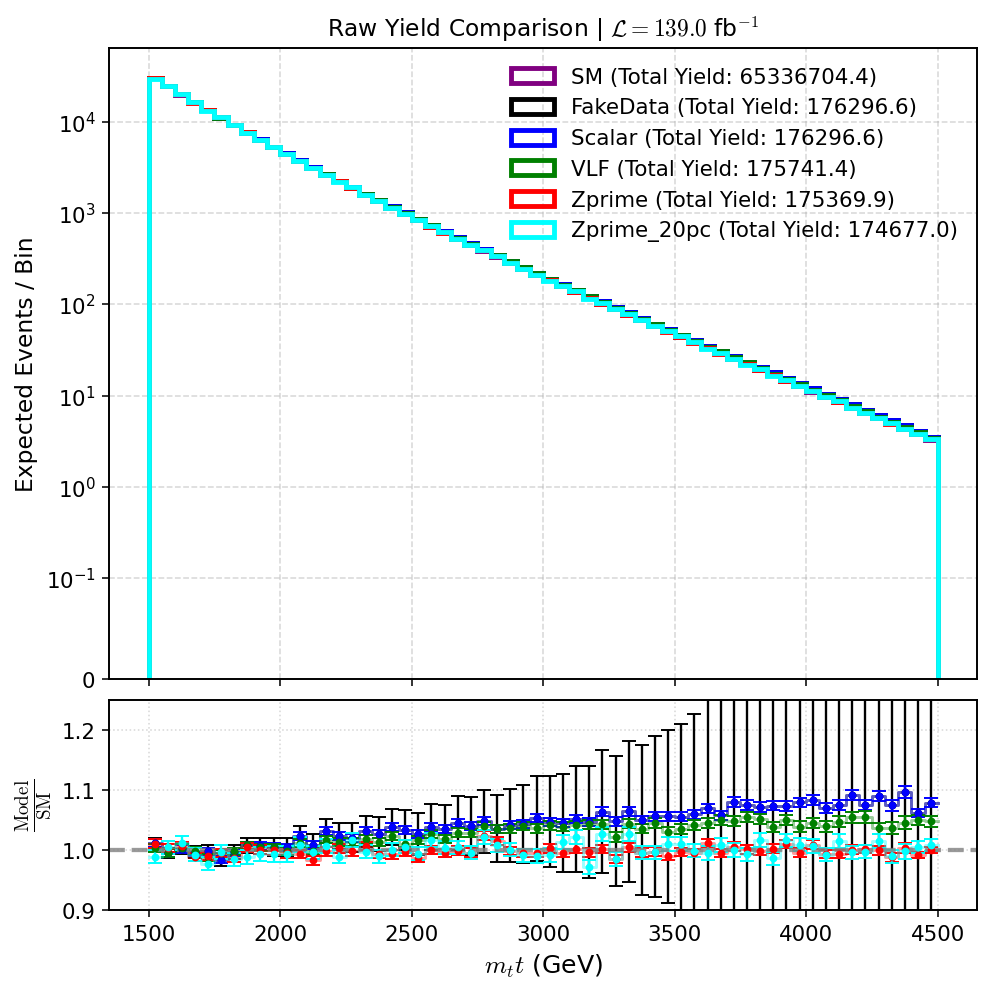

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_weighted_histograms(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False, sys_err=0.0):
    """
    Plots superimposed 1D distributions (Main) and their ratio to SM (Sub-panel) with Error Bars.
    Distributions are plotted with their raw expected yields for the given luminosity.
    Negative weights (e.g., from NLO interference) are fully preserved.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]

    # --- Define Color Mapping Here ---
    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # 1. Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    # 2. Extract and Bin SM (Calculating Sum of Squared Weights for Error)
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sys_err * h_sm)**2)

    hist_data['SM'] = {'h': h_sm, 'err': hErr_sm, 'lbl': f"SM (Total Yield: {np.sum(w_sm):.1f})"}

    # 3. Extract and Bin BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)

        # Determine specific error type based on Model vs Data
        if lab_str == 'FakeData':
            # Poisson statistical uncertainty for "Data"
            err = np.sqrt(np.abs(h))
        else:
            # MC Sum of Squared Weights for BSM Models
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq)

        hist_data[lab_str] = {'h': h, 'err': err, 'lbl': f"{lab_str} (Total Yield: {np.sum(h):.1f})"}

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():

        # Get the assigned color, defaulting to 'gray' if not found
        c = color_map.get(lab_str, 'gray')

        # Plot the main step histogram
        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c)

        # Compute and plot the ratio to SM with Error Bars
        if lab_str != 'SM':
            with np.errstate(divide='ignore', invalid='ignore'):
                # 1. Calculate Ratio
                ratio = np.where(h_sm > 0, data['h'] / h_sm, np.nan)

                # 2. Propagate Error: delta_R = (1/SM) * sqrt( err_BSM^2 + (Ratio * err_SM)^2 )
                ratio_err = np.where(
                    h_sm > 0,
                    (1.0 / h_sm) * np.sqrt(data['err']**2 + (ratio**2 * hErr_sm**2)),
                    np.nan
                )

            # Plot error bars at bin centers
            ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, color=c,
                              fmt='o', ms=3, capsize=3.5, elinewidth=1.2)

            # Keep the faint step line connecting the points to match original aesthetic
            ratio_padded = np.append(ratio, ratio[-1])
            ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=0.4)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    # Main Axes
    ax_main.set_title(rf"Raw Yield Comparison | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=12)
    ax_main.set_ylabel("Density" if density else "Expected Events / Bin", fontsize=12)
    ax_main.legend(loc="best", framealpha=1.0)

    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    # Ratio Axes
    ax_ratio.axhline(1.0, color='gray', linestyle='--', alpha=0.8) # Changed to 1.0 for standard ratio
    ax_ratio.set_xlabel(rf'${var}$ (GeV)' if var == 'm_tt' else var, fontsize=13)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Model}}{\mathrm{SM}}$", fontsize=14)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)
    ax_ratio.set_ylim(0.9, 1.25)

    plt.tight_layout()
    plt.show()
# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [
    ("m_tt", (300, 5000)),
]

LUMI = 139.0

for v, rng in observables:
    plot_raw_weighted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=(1500,4500),
        density=False,
        sys_err=0.00
    )

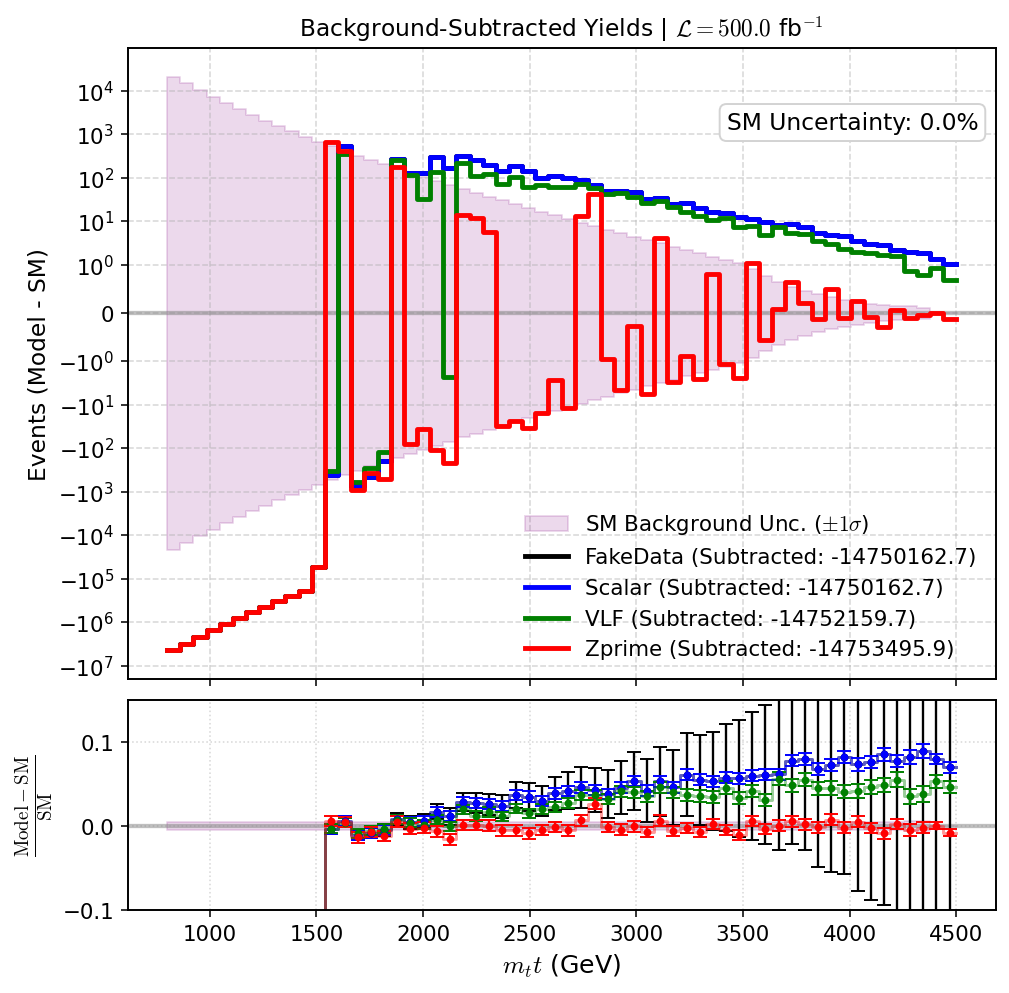

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_subtracted_histograms(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, sys_err=0.05):
    """
    Plots SM-subtracted 1D distributions (Main) and their fractional difference (Sub-panel).
    Accounts for both statistical MC error and SM systematic error in the subtraction.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime", ] #"Zprime_20pc"

    # --- Define Color Mapping Here ---
    color_map = {
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # 1. Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    hist_data = {}

    # 2. Extract and Bin SM
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm)
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sys_err * h_sm)**2)

    # 3. Extract, Bin, and Subtract BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w)

        # Determine specific error type based on Model vs Data
        if lab_str == 'FakeData':
            err = np.sqrt(np.abs(h)) # Poisson Data Stat
        else:
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq) # MC Stat

        # --- THE SUBTRACTION ---
        h_sub = h - h_sm

        # Propagate Subtracted Error: sqrt(Err_model^2 + Err_SM^2)
        err_sub = np.sqrt(err**2 + hErr_sm**2)

        hist_data[lab_str] = {
            'h_sub': h_sub, 'err_sub': err_sub,
            'h_raw': h, 'err_raw': err,
            'lbl': f"{lab_str} (Subtracted: {np.sum(h_sub):.1f})"
        }

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # --- Plot SM Reference Band centered at Zero ---
    err_band_main = np.append(hErr_sm, hErr_sm[-1])
    ax_main.axhline(0, color='gray', linestyle='-', alpha=0.5)
    ax_main.fill_between(bin_edges, -err_band_main, err_band_main, step='post',
                         color='purple', alpha=0.15, label=r'SM Background Unc. ($\pm 1\sigma$)')

    with np.errstate(divide='ignore', invalid='ignore'):
        rel_sm_err = np.where(h_sm > 0, hErr_sm / h_sm, 0)
    err_band_ratio = np.append(rel_sm_err, rel_sm_err[-1])
    ax_ratio.axhline(0, color='gray', linestyle='-', alpha=0.5)
    ax_ratio.fill_between(bin_edges, -err_band_ratio, err_band_ratio, step='post',
                          color='purple', alpha=0.15)

    # --- Plot BSM Subtracted Lines ---
    for lab_str, data in hist_data.items():
        c = color_map.get(lab_str, 'gray')

        # Plot Subtracted Yield in Main Panel (Using Step function)
        padded_sub = np.append(data['h_sub'], data['h_sub'][-1])
        ax_main.step(bin_edges, padded_sub, where='post', linewidth=2.5, label=data['lbl'], color=c)

        # Compute Fractional Difference: (Model - SM) / SM
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(h_sm > 0, data['h_sub'] / h_sm, np.nan)

            # Error on (Model - SM)/SM is identical to error on Model/SM
            ratio_err = np.where(
                h_sm > 0,
                (1.0 / h_sm) * np.sqrt(data['err_raw']**2 + (data['h_raw']/h_sm)**2 * hErr_sm**2),
                np.nan
            )

        # Plot Ratio Panel
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, color=c,
                          fmt='o', ms=3, capsize=3.5, elinewidth=1.2)
        ratio_padded = np.append(ratio, ratio[-1])
        ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=0.4)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    # Main Axes
    ax_main.set_title(rf"Background-Subtracted Yields | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=12)
    ax_main.set_ylabel(r"Events (Model - SM)", fontsize=12)
    ax_main.legend(loc="lower right", framealpha=1.0)
    # Place the SM Uncertainty Box safely using .format()
    sm_text = r"SM Uncertainty: {:.1f}%".format(sys_err * 100)
    ax_main.text(0.98, 0.90, sm_text,
        transform=ax_main.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=1.0))


    # Symlog is perfect here because subtracted yields cross below zero!
    ax_main.set_yscale('symlog', linthresh=1.0)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    # Ratio Axes
    ax_ratio.set_xlabel(rf'${var}$ (GeV)' if var == 'm_tt' else var, fontsize=13)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Model} - \mathrm{SM}}{\mathrm{SM}}$", fontsize=14)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)
    ax_ratio.set_ylim(-0.1,0.15)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [("m_tt", (800, 4500))]

LUMI = 500.0

for v, rng in observables:
    plot_subtracted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=rng,
        sys_err=0.00  # Keep this explicitly at 0.05 to activate your SM systematic error!
    )

In [7]:
# ------------------------------------------------------------
# m_cut Scan Configuration
# ------------------------------------------------------------
labels = ["FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]
mcuts = [ 1500, 1800, 2000, 2200, 2500]
mcut_max = 4_500
bin_width = 100.0
L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# ------------------------------------------------------------
# Luminosity Scan Configuration (Notebook)
# ------------------------------------------------------------
lumi_targets = [300., 500., 1000., 1500., 2000., 2500., 3000.]

# ------------------------------------------------------------
# Data Extraction
# ------------------------------------------------------------
var = "m_tt"  # Variable of the distributions

# Clean the DataFrames
df_sm_clean = df_sm[[var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_sm_clean = df_sm_clean[df_sm_clean[var] > 0]

df_hyp_clean = df_bsm[["label", var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_clean = df_hyp_clean[df_hyp_clean[var] > 0]

# Extract into pure NumPy dictionaries
sm_data = {
    "x": df_sm_clean[var].values,
    "w": df_sm_clean["weight"].values
}

bsm_data = {}
for lab, sub in df_hyp_clean.groupby("label"):
    lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
    if lab_str in labels:
        bsm_data[lab_str] = {
            "x": sub[var].values,
            "w": sub["weight"].values
        }

# ------------------------------------------------------------
# Load the m cut and luminosity scan data frames
# ------------------------------------------------------------
df_mcut = hp.run_fast_mcut_scan(sm_data, bsm_data, labels, mcuts=mcuts,
                                mcut_max=mcut_max, bin_width=bin_width,
                                L_target=L_target, eps_values=eps_values,
                                fake_model='FakeData', sig_norm = False)

# Run the scan once to calculate both Shape and Falloff metrics but for luminosity
df_lumi = hp.run_fast_lumi_scan(sm_data, bsm_data, labels, target_mcut=1500, mcut_max=4500,
                                bin_width=100.0, lumi_targets=lumi_targets, eps_values=eps_values,
                                fake_model='FakeData', sig_norm = False)


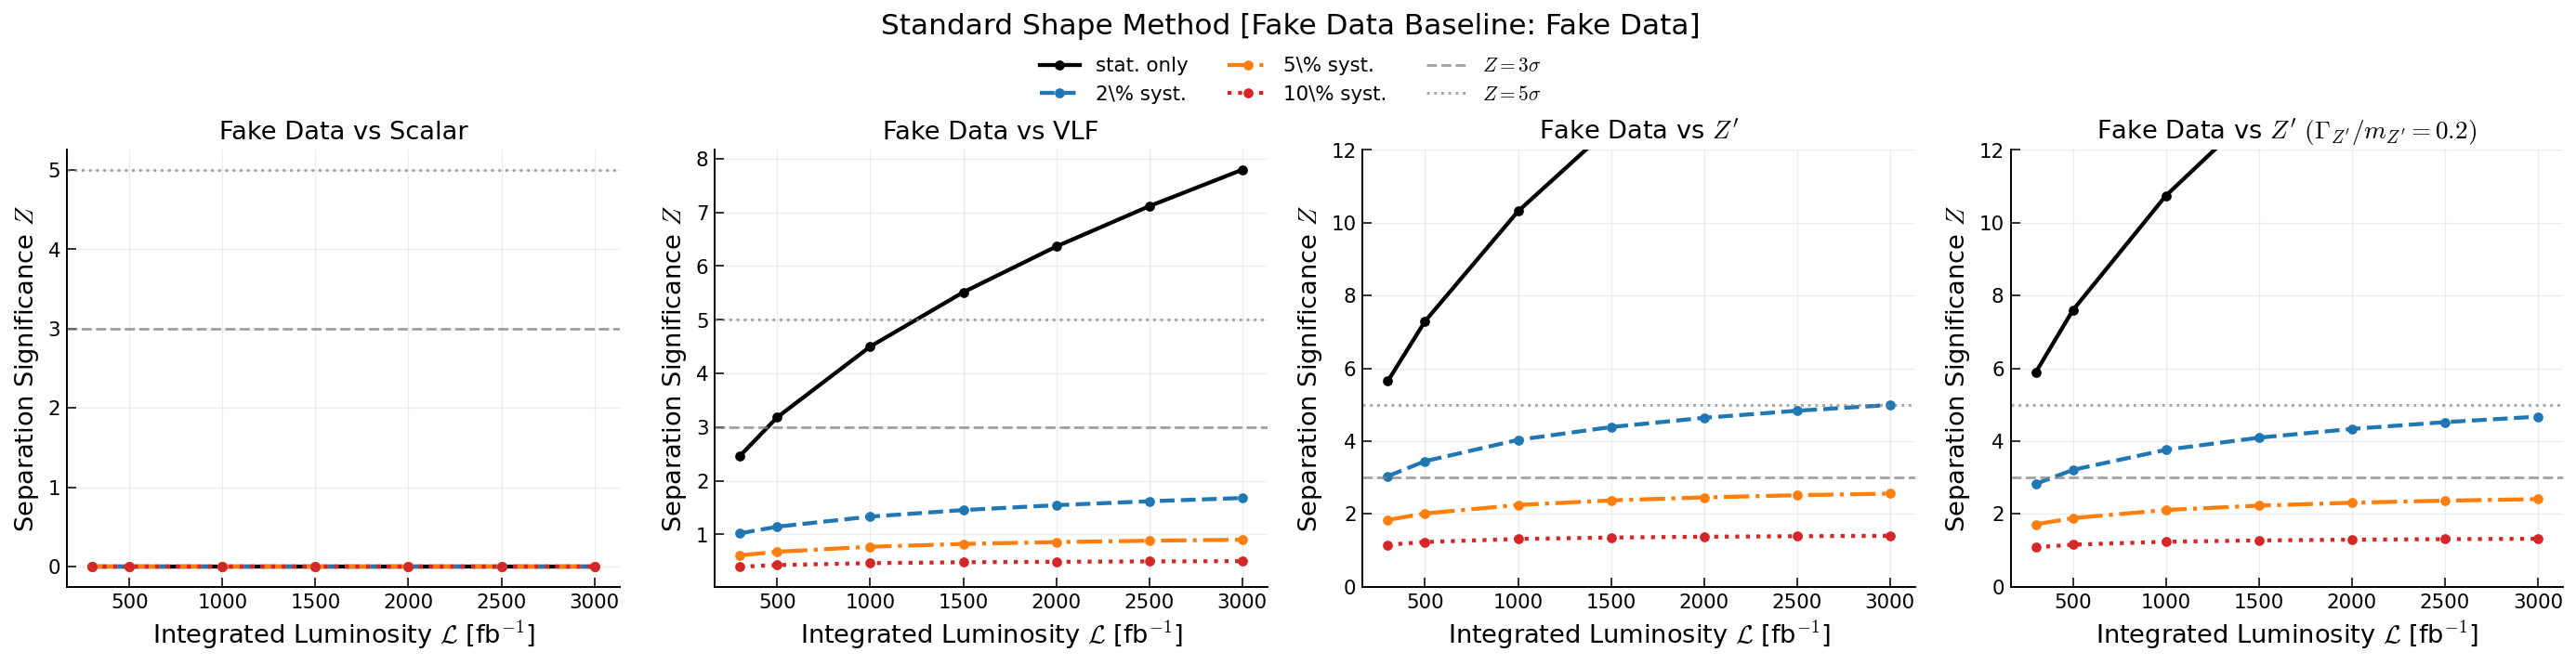

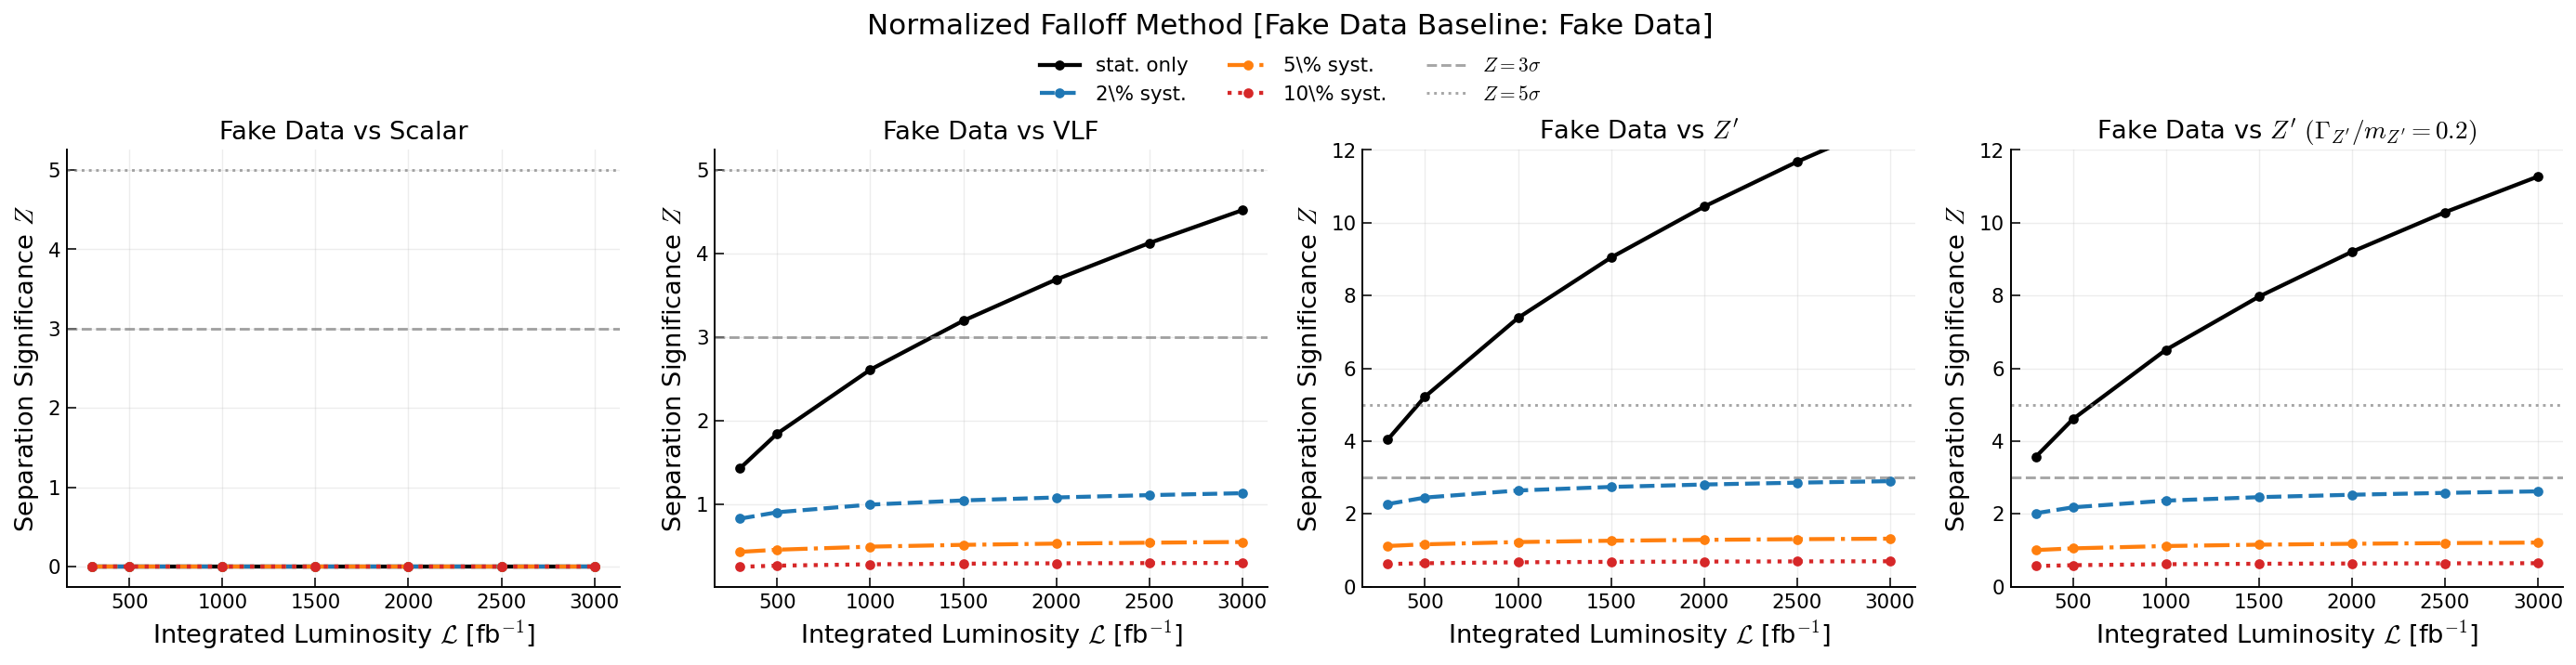

In [8]:
# Create output directory
outdir = Path("paper_plots_systematics")
outdir.mkdir(parents=True, exist_ok=True)

#  Plot Mass Cut Scans
#hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="sh",
 #                      outfile=outdir / "syst_grid_mcut_shape.pdf",
  #                     fake_model='FakeData')

#hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="fa",
 #                      outfile=outdir / "syst_grid_mcut_falloff.pdf",
  #                     fake_model='FakeData')

# Plot Luminosity Scans
hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_lumi_shape.pdf",
                       shareY = False, fake_model='FakeData')

hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="fa",
                       outfile=outdir / "syst_grid_lumi_falloff.pdf",
                       shareY= False, fake_model='FakeData')


#hp.plot_ratio_pairwise(df_mcut, mcut_max, eps_values,
 #                      outfile=outdir / "improvement_ratio_mcut.pdf")

#hp.plot_ratio_pairwise_lumi(df_lumi, target_mcut=1500, eps_values=eps_values,
 #                           outfile=outdir / "improvement_ratio_lumi.pdf")


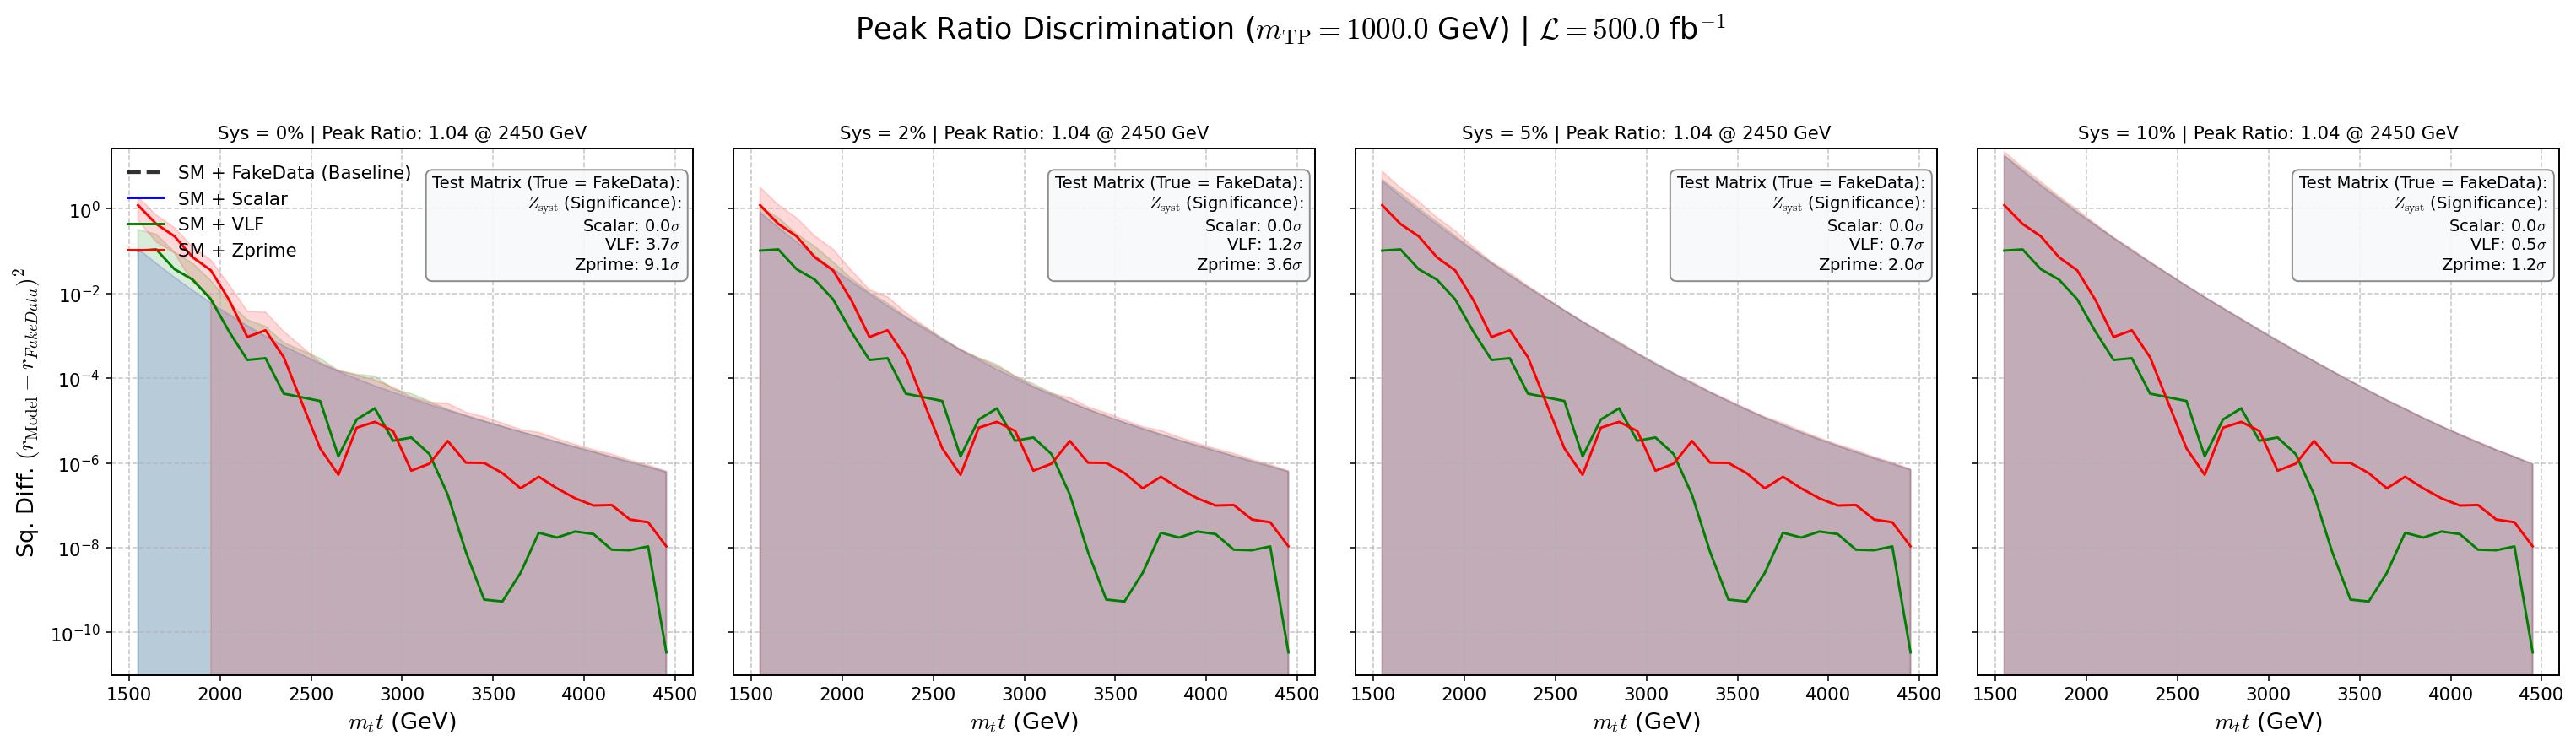


--- Significance Dictionary Exported ---
Saved successfully to: post_peak_ratios_significances.npz


In [12]:
def post_peak_ratio_sys_scan(df_sm, df_bsm, target_models=["FakeData", "Scalar", "VLF", "Zprime"],
                             var="m_tt", mTP=1000.0, lum=500.0,
                             bins=60, rng=(1500, 4500),
                             peak_search_rng=(1500, 2500),
                             asimov_model='FakeData',
                             n_bp=17, n_ap=26, sm_sys_err_list=[0.0, 0.02, 0.05, 0.10],
                             out_filename='post_peak_ratios_significances.npz'):
    """
    Scans over systematic uncertainties. Finds the peak dynamically via the max Data/SM ratio.
    Computes post-peak ratios, evaluates the Covariance Matrices, and plots the
    SQUARED absolute differences (Model - Baseline)^2 with robust second-order error bands.
    """
    def get_cols(df):
        l_col = "label" if "label" in df.columns else "model"
        w_col = "weight" if "weight" in df.columns else "w_norm"
        return l_col, w_col

    bin_edges = np.arange(rng[0], rng[1] + 100, 100)
    bin_centers_full = bin_edges[:-1] + np.diff(bin_edges)/2
    sys_q_dict = {}

    # ==========================================
    # 1. Extract Base Histograms
    # ==========================================
    lbl_sm, wgt_sm = get_cols(df_sm)
    df_sm_clean = df_sm[[lbl_sm, var, wgt_sm]].replace([np.inf, -np.inf], np.nan).dropna()
    x_sm = df_sm_clean[var].values
    w_sm = df_sm_clean[wgt_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm)
    var_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    lbl_bsm, wgt_bsm = get_cols(df_bsm)
    df_bsm_clean = df_bsm[[lbl_bsm, var, wgt_bsm]].replace([np.inf, -np.inf], np.nan).dropna()

    raw_signals = {}
    for sig in target_models:
        sig_df = df_bsm_clean[df_bsm_clean[lbl_bsm].astype(str) == sig]
        if not sig_df.empty:
            x_sig = sig_df[var].values
            w_sig = sig_df[wgt_bsm].values * lum * 1000.0
            h_sig, _ = np.histogram(x_sig, bins=bin_edges, weights=w_sig)
            v_sig, _ = np.histogram(x_sig, bins=bin_edges, weights=w_sig**2)
            raw_signals[sig] = {'h_sig': h_sig, 'v_sig': v_sig}

    if asimov_model not in raw_signals:
        raise ValueError(f"Asimov baseline model '{asimov_model}' not found in df_bsm.")

    model_significances = {}
    x_centers_dict = {}
    fig, axes = plt.subplots(1, len(sm_sys_err_list), figsize=(5.5 * len(sm_sys_err_list), 6), sharey=True)
    axes = np.atleast_1d(axes)

    # ==========================================
    # 2. Loop Over Systematic Errors
    # ==========================================
    for idx, sys_err in enumerate(sm_sys_err_list):
        ax = axes[idx]

        hypotheses = {}
        for sig, data in raw_signals.items():
            h_tot =  data['h_sig']
            err_tot = np.sqrt( data['v_sig'] + (sys_err * h_sm)**2)
            hypotheses[sig] = {'h': h_tot, 'err': err_tot}

        h_asimov = hypotheses[asimov_model]['h']
        excess_ratio = np.divide(h_asimov, h_sm, out=np.zeros_like(h_asimov), where=h_sm > 0)

        range_mask = (bin_centers_full >= peak_search_rng[0]) & (bin_centers_full <= peak_search_rng[1])
        valid_mask = range_mask & (h_sm > 0)

        valid_indices = np.where(valid_mask)[0]
        if len(valid_indices) == 0:
             raise ValueError(f"No valid bins with SM > 0 found in the range {peak_search_rng}.")

        b_peak = valid_indices[np.argmax(excess_ratio[valid_indices])]

        start_idx = max(0, b_peak - n_bp)
        end_idx = min(len(bin_edges)-1, b_peak + n_ap)
        peak_local_idx = b_peak - start_idx
        x_centers = bin_centers_full[start_idx:end_idx]
        x_centers_dict[sys_err] = x_centers

        ratios_dict = {}
        for name, data in hypotheses.items():
            h, herr = data['h'], data['err']
            aux, err = [], []
            for j in range(start_idx, end_idx):
                A, B = h[j], h[b_peak]
                errA, errB = herr[j], herr[b_peak]
                val = A / B if B > 0 else 0
                aux.append(val)
                safe_err = val * np.sqrt((errA / A)**2 + (errB / B)**2) if (A > 0 and B > 0) else 0.0
                err.append(safe_err)
            ratios_dict[name] = {'r': np.array(aux), 'err': np.array(err)}

        r_A = ratios_dict[asimov_model]['r']
        stats_mask = np.arange(len(r_A)) != peak_local_idx
        valid_r_A = r_A[stats_mask]
        N_eval = len(valid_r_A)

        stats_lines = [
            rf"Test Matrix (True = {asimov_model}):",
            r"$Z_{\mathrm{syst}}$ (Significance):"
        ]
        q_dict = {}
        sym_err_dict = {}

        for name in hypotheses.keys():
            q_name_dict = {}
            if name == asimov_model:
                continue

            r_B = ratios_dict[name]['r'][stats_mask]

            n_B = hypotheses[name]['h'][start_idx:end_idx][stats_mask]
            n_peak_B = hypotheses[name]['h'][b_peak]

            n_ref = n_B
            n_peak_ref = n_peak_B
            r_ref = r_B

            C_ref = np.zeros((N_eval, N_eval))
            eps = sys_err

            peak_var_term = (1.0 + (eps**2) * n_peak_ref) / n_peak_ref if n_peak_ref > 0 else 0.0

            for i in range(N_eval):
                for j in range(N_eval):
                    if i == j:
                        bin_var_term = (1.0 + (eps**2) * n_ref[i]) / n_ref[i] if n_ref[i] > 0 else 0.0
                        C_ref[i, j] = (r_ref[i]**2) * (bin_var_term + peak_var_term)
                    else:
                        C_ref[i, j] = r_ref[i] * r_ref[j] * peak_var_term

            try:
                C_inv = np.linalg.inv(C_ref)
            except np.linalg.LinAlgError:
                C_inv = np.diag(1.0 / np.diag(C_ref))

            sym_err_dict[name] = np.sqrt(np.diag(C_ref))

            delta_r = valid_r_A - r_B
            q_name_dict['num'] = delta_r
            q_name_dict['denom'] = np.diag(np.diag(C_inv))
            q_name_dict['offd'] = C_inv - np.diag(np.diag(C_inv))

            q_A = delta_r.T @ C_inv @ delta_r
            Z_score = max(np.sqrt(q_A), 0.0)
            q_dict[name] = q_name_dict

            if name not in model_significances:
                model_significances[name] = {}
            model_significances[name][sys_err] = {
                'sqrt_chi2': Z_score,
                'z_score': Z_score
            }

            stats_lines.append(rf"{name}: {Z_score:.1f}$\sigma$")

        sys_q_dict[sys_err] = q_dict

        # ==========================================
        # 3. Fill Subplot (SQUARED Difference Format)
        # ==========================================
        colors = {'FakeData': 'black', 'Scalar': 'blue', 'VLF': 'green', 'Zprime': 'red'}

        r_base = ratios_dict[asimov_model]['r']

        # Initialize y limits. Since it's squared, the minimum will realistically be 0.
        y_min_plot, y_max_plot = 0.0, 0.0001

        for name in hypotheses.keys():
            lbl = f"SM + {name}"
            c = colors.get(name, 'magenta')

            if name == asimov_model:
                # Baseline is exactly 0 in a squared difference plot
                ax.axhline(0.0, color='k', linestyle='--', alpha=0.8, zorder=4, label=f"{lbl} (Baseline)")
            else:
                x_plot = x_centers[stats_mask]
                r_base_plot = r_base[stats_mask]
                r_model_plot = ratios_dict[name]['r'][stats_mask]

                # Step 1: Calculate raw difference
                raw_diff = r_model_plot - r_base_plot

                # Step 2: Calculate Squared Difference (Model - Baseline)^2
                y_val = raw_diff**2
                ax.plot(x_plot, y_val, label=lbl, color=c, markersize=4, linewidth=1.5, zorder=3)

                # Step 3: Propagate error robustly for Z = Y^2
                # Var(Z) = 4 * Y^2 * Var(Y) + 2 * (Var(Y))^2
                y_err = sym_err_dict[name]
                z_err = np.sqrt(4 * (raw_diff**2) * (y_err**2) + 2 * (y_err**4))

                ax.fill_between(x_plot, y_val - z_err, y_val + z_err, color=c, alpha=0.15, zorder=1)

                valid_y = y_val[np.isfinite(y_val)]
                if len(valid_y) > 0:
                    # We bound minimum at 0.0 to prevent scaling out of bounds since squares can't be negative
                    y_max_plot = max(y_max_plot, np.max(valid_y))

                valid_err_top = (y_val + z_err)[np.isfinite(z_err)]
                if len(valid_err_top) > 0:
                    y_max_plot = max(y_max_plot, np.max(valid_err_top))

        ax.set_xlabel(rf'${var}$ (GeV)', fontsize=14)
        ax.set_yscale('log')
        if idx == 0:
            ax.set_ylabel(rf'Sq. Diff. $(r_{{\mathrm{{Model}}}} - r_{{{asimov_model}}})^2$', fontsize=14)

        chosen_peak_mass = bin_centers_full[b_peak]
        max_ratio_val = excess_ratio[b_peak]
        ax.set_title(rf'Sys = {sys_err * 100:.0f}% | Peak Ratio: {max_ratio_val:.2f} @ {chosen_peak_mass:.0f} GeV', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.7)

        # Scale limits tightly. Negative y-limit is just padding for the zero line.
        y_range = y_max_plot
        ax.set_ylim(- (y_range * 0.05), y_max_plot + (y_range * 0.2))

        if idx == 0:
            ax.legend(fontsize=11, framealpha=1.0, loc='upper left')

        stats_text = "\n".join(stats_lines)
        ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

    # ==========================================
    # FINALIZATION
    # ==========================================
    fig.suptitle(rf'Peak Ratio Discrimination ($m_{{\mathrm{{TP}}}} = {mTP}$ GeV) | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$', fontsize=18, y=1.05)
    plt.tight_layout()
    plt.savefig('Squared_Difference_Curves_Sys_Scan.pdf', bbox_inches='tight')
    plt.show()

    print("\n--- Significance Dictionary Exported ---")
    np.savez(out_filename, results=model_significances)
    print(f"Saved successfully to: {out_filename}")

    return x_centers_dict, sys_q_dict
# ============================================================
# Execution Example
# ============================================================
x_centers, sys_q_dict = post_peak_ratio_sys_scan(
     df_sm=df_sm,
     df_bsm=df_bsm,
     target_models=["FakeData", "Scalar", "VLF", "Zprime"],
     var="m_tt",
     mTP=1000.0,
     lum=500.0,
     bins=60,
     rng=(1500, 4500),
     asimov_model='FakeData',
     n_bp=18,
     n_ap=27,
     sm_sys_err_list=[0.0, 0.02, 0.05, 0.10],
     out_filename='post_peak_ratios_significances.npz'
)

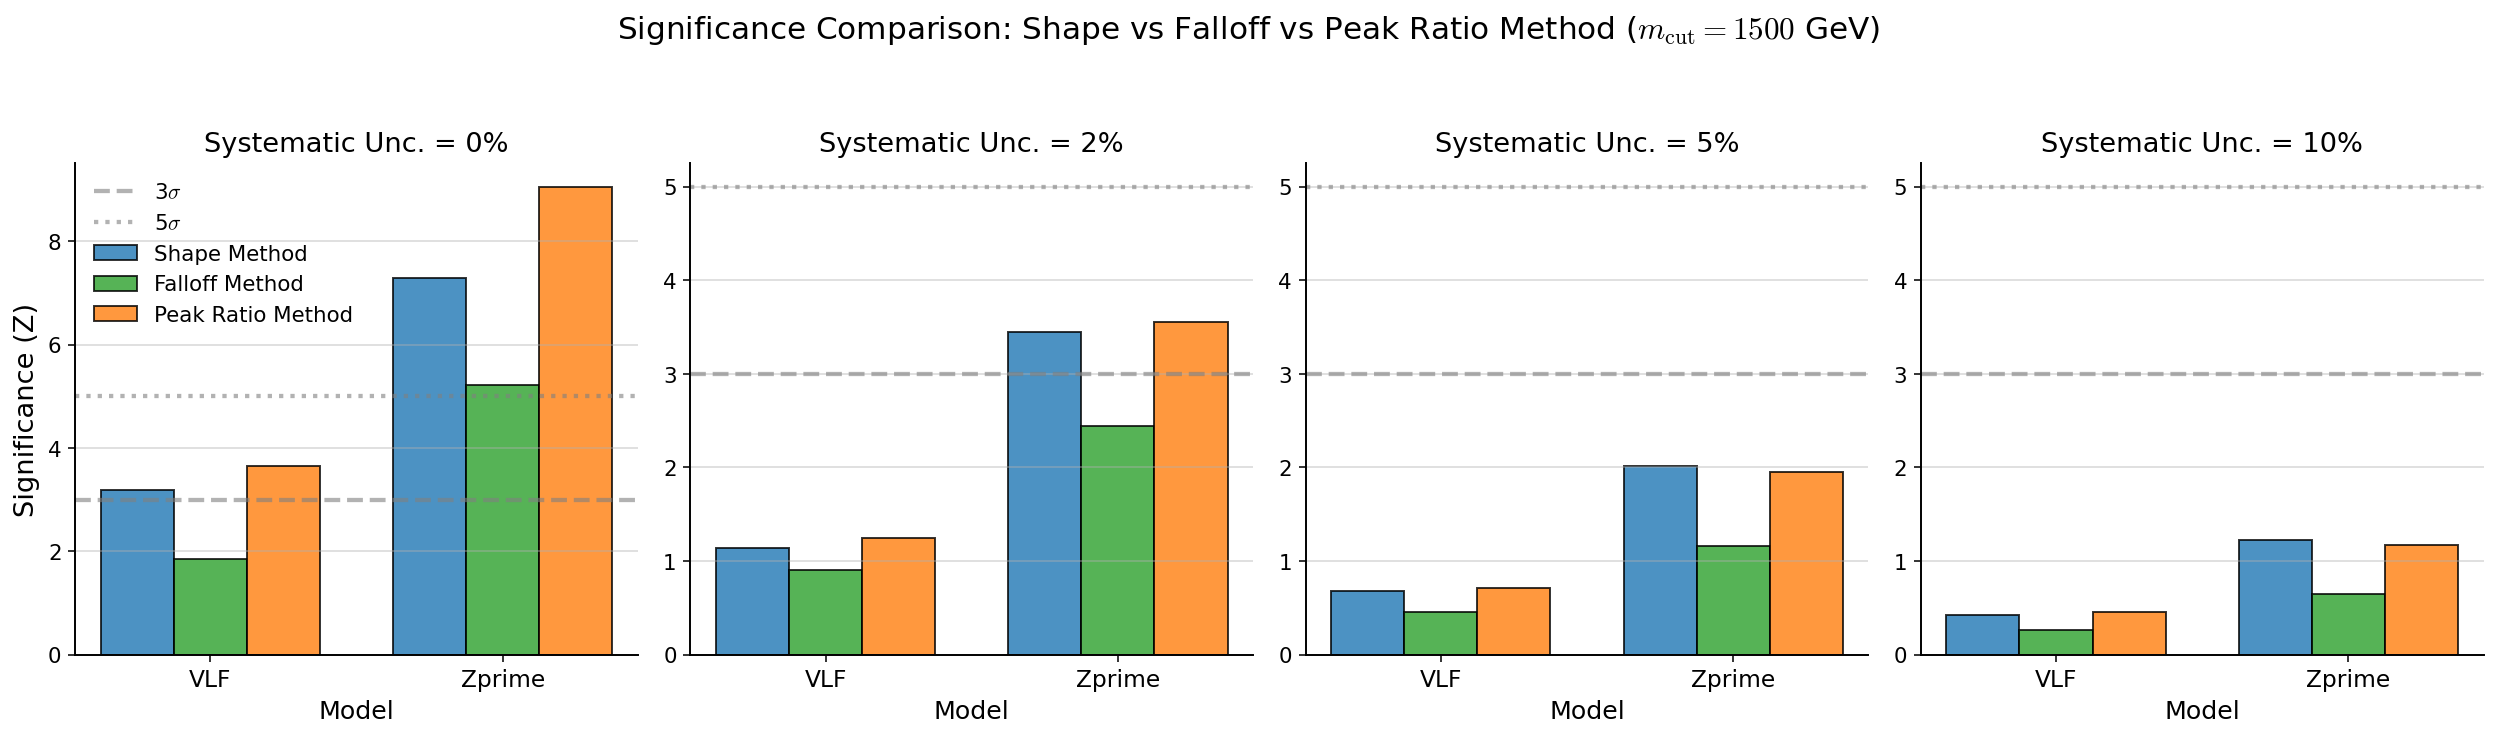

Results successfully compiled and saved to 'compiled_method_comparison_FullSample.npy'


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Configuration & Data Loading
# -------------------------------------------------------------------
dict_path = './post_peak_ratios_significances.npz'

# Load the dictionary securely.
loaded_data = np.load(dict_path, allow_pickle=True)
if 'results' in loaded_data:
    post_peak_dict = loaded_data['results'].item()
else:
    post_peak_dict = {k: loaded_data[k].item() for k in loaded_data.files}

# Define the pairings and the X-axis labels
target_mcut = 1500

# Update to the new 'FakeData vs Model' naming convention used in df_mcut
pairs = ['FakeData vs VLF', 'FakeData vs Zprime']
x_labels = ['VLF', 'Zprime'] # The second name in the comparison
eps_values = [0.0, 0.02, 0.05, 0.10]

# -------------------------------------------------------------------
# Extract, Align, and Save the Data
# -------------------------------------------------------------------
df_sub = df_mcut[df_mcut['mcut'] == target_mcut]

shape_data = {eps: [] for eps in eps_values}
falloff_data = {eps: [] for eps in eps_values}
post_peak_data = {eps: [] for eps in eps_values}

# NEW: Initialize the master dictionary to save all extracted results
compiled_results = {model: {eps: {} for eps in eps_values} for model in x_labels}

for i, pair in enumerate(pairs):
    model = x_labels[i]
    row = df_sub[df_sub['pair'] == pair]

    # Match the model name (ignores spaces, cases, and underscores)
    matched_model_key = None
    clean_target = model.lower().replace(" ", "").replace("_", "")
    for k in post_peak_dict.keys():
        clean_k = str(k).lower().replace(" ", "").replace("_", "")
        if clean_target in clean_k:
            matched_model_key = k
            break

    if matched_model_key is None:
        print(f"WARNING: Could not find any match for model '{model}' in the dictionary!")

    for eps in eps_values:
        # Extract Shape Method Z-score
        col_name_sh = f"Z_sh_eps_{int(100*eps):02d}"
        if not row.empty and col_name_sh in row.columns:
            z_shape = row[col_name_sh].values[0]
        else:
            z_shape = 0.0
        shape_data[eps].append(z_shape)

        # Extract Falloff Method Z-score
        col_name_fa = f"Z_fa_eps_{int(100*eps):02d}"
        if not row.empty and col_name_fa in row.columns:
            z_falloff = row[col_name_fa].values[0]
        else:
            z_falloff = 0.0
        falloff_data[eps].append(z_falloff)

        # Extract Post-Peak sqrt(chi^2)
        val_post_peak = 0.0
        if matched_model_key is not None:
            model_dict = post_peak_dict[matched_model_key]
            for dict_eps, dict_vals in model_dict.items():
                if np.isclose(eps, dict_eps, atol=1e-5):
                    # Handle the nested dictionary structure
                    if isinstance(dict_vals, dict) and 'z_score' in dict_vals:
                        val_post_peak = dict_vals['z_score']
                    else:
                        print('Oh no')
                    break

        post_peak_data[eps].append(val_post_peak)

        # NEW: Save the specific values to the compiled dictionary
        compiled_results[model][eps] = {
            'Shape': z_shape,
            'Falloff': z_falloff,
            'PeakRatio': val_post_peak
        }

# -------------------------------------------------------------------
# Plotting the Comparison Grid
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, len(eps_values), figsize=(18, 5), sharey=False)

x_indices = np.arange(len(x_labels))

# Narrow the bar width to fit 3 bars side-by-side
bar_width = 0.25

# Custom colors for the three methods
color_shape = '#1f77b4'      # Blue
color_falloff = '#2ca02c'    # Green
color_post_peak = '#ff7f0e'  # Orange

for i, eps in enumerate(eps_values):
    ax = axes[i]

    sh_vals = shape_data[eps]
    fa_vals = falloff_data[eps]
    pp_vals = post_peak_data[eps]

    # Plot grouped bars: offset by -bar_width, 0, and +bar_width
    ax.bar(x_indices - bar_width, sh_vals, bar_width, label='Shape Method', color=color_shape, edgecolor='black', alpha=0.8)
    ax.bar(x_indices, fa_vals, bar_width, label='Falloff Method', color=color_falloff, edgecolor='black', alpha=0.8)
    ax.bar(x_indices + bar_width, pp_vals, bar_width, label='Peak Ratio Method', color=color_post_peak, edgecolor='black', alpha=0.8)

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(f'Systematic Unc. = {int(eps*100)}%', fontsize=14)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_xlabel('Model', fontsize=13)

    # Draw reference lines for 3-sigma (evidence) and 5-sigma (discovery)
    ax.axhline(3.0, color='gray', linestyle='--', alpha=0.6, label=r'3$\sigma$')
    ax.axhline(5.0, color='gray', linestyle=':', alpha=0.6, label=r'5$\sigma$')

    if i == 0:
        ax.set_ylabel('Significance (Z)', fontsize=14)
        # Deduplicate legend handles (so 3/5 sigma lines only appear once)
        handles, labels_ = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=False)

    ax.grid(axis='y', linestyle='-', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(rf'Significance Comparison: Shape vs Falloff vs Peak Ratio Method ($m_{{\mathrm{{cut}}}} = {target_mcut}$ GeV)', fontsize=16, y=1.05)

plt.tight_layout()
plt.savefig('Comparison_Shape_vs_Falloff_vs_PostPeak.pdf', bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------
# Export the Compiled Results
# -------------------------------------------------------------------
output_dict_name = 'compiled_method_comparison_FullSample.npy'
np.save(output_dict_name, compiled_results)
print(f"Results successfully compiled and saved to '{output_dict_name}'")

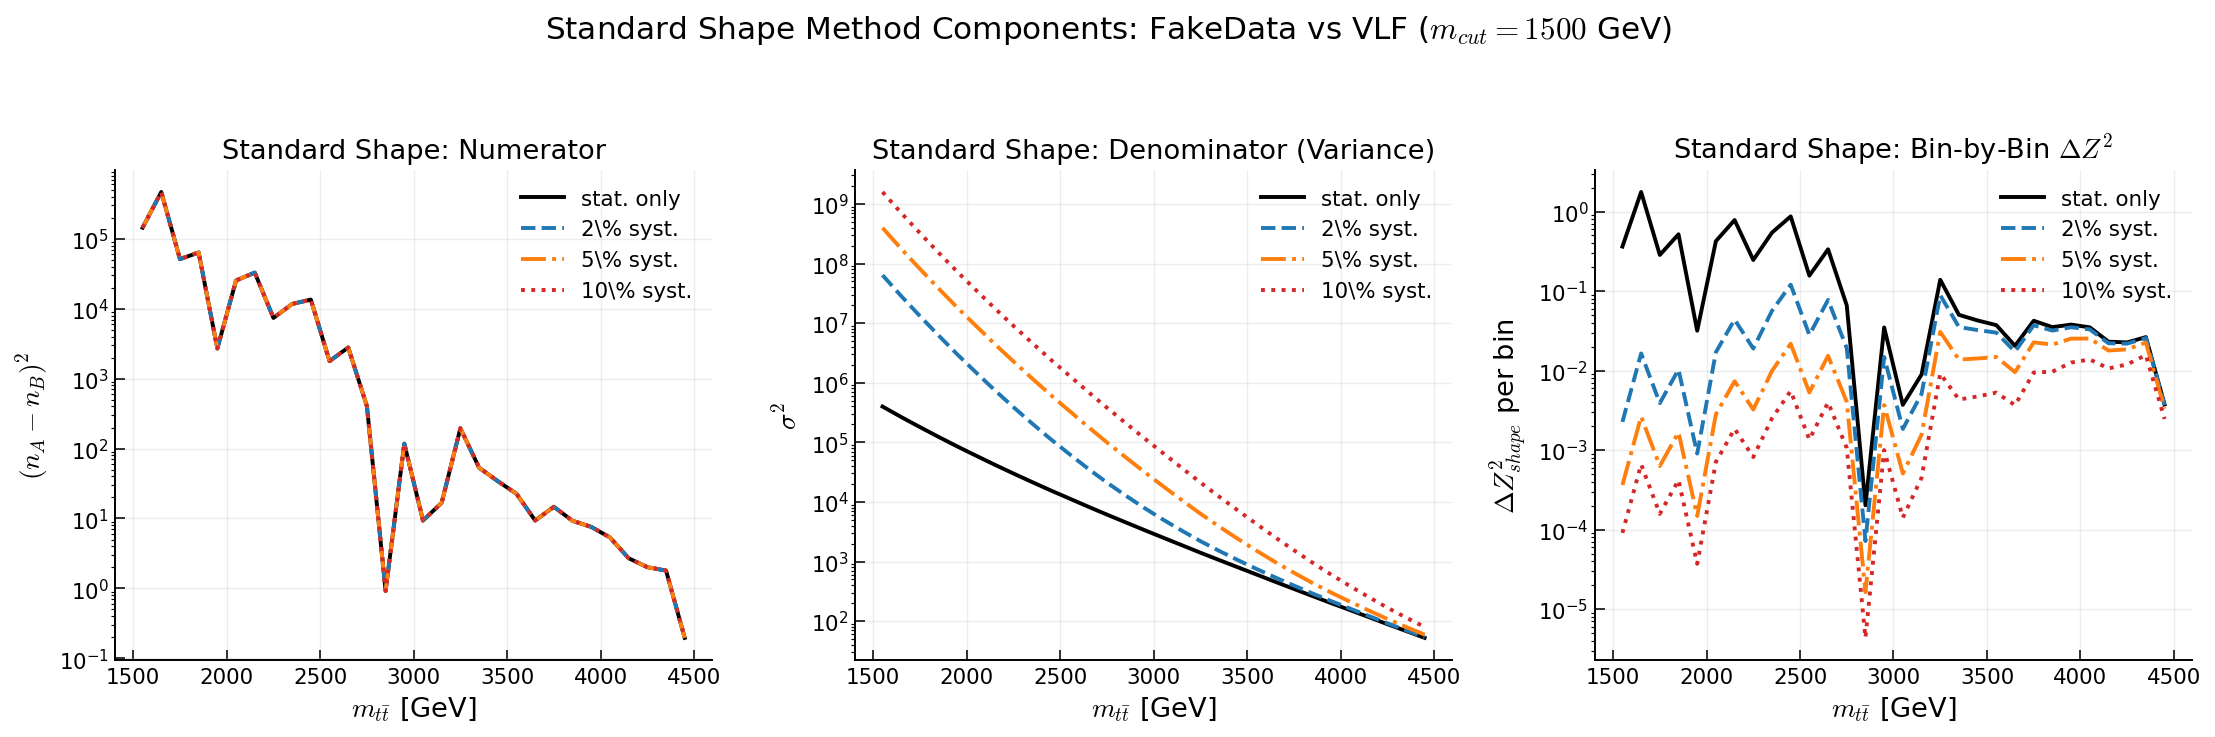

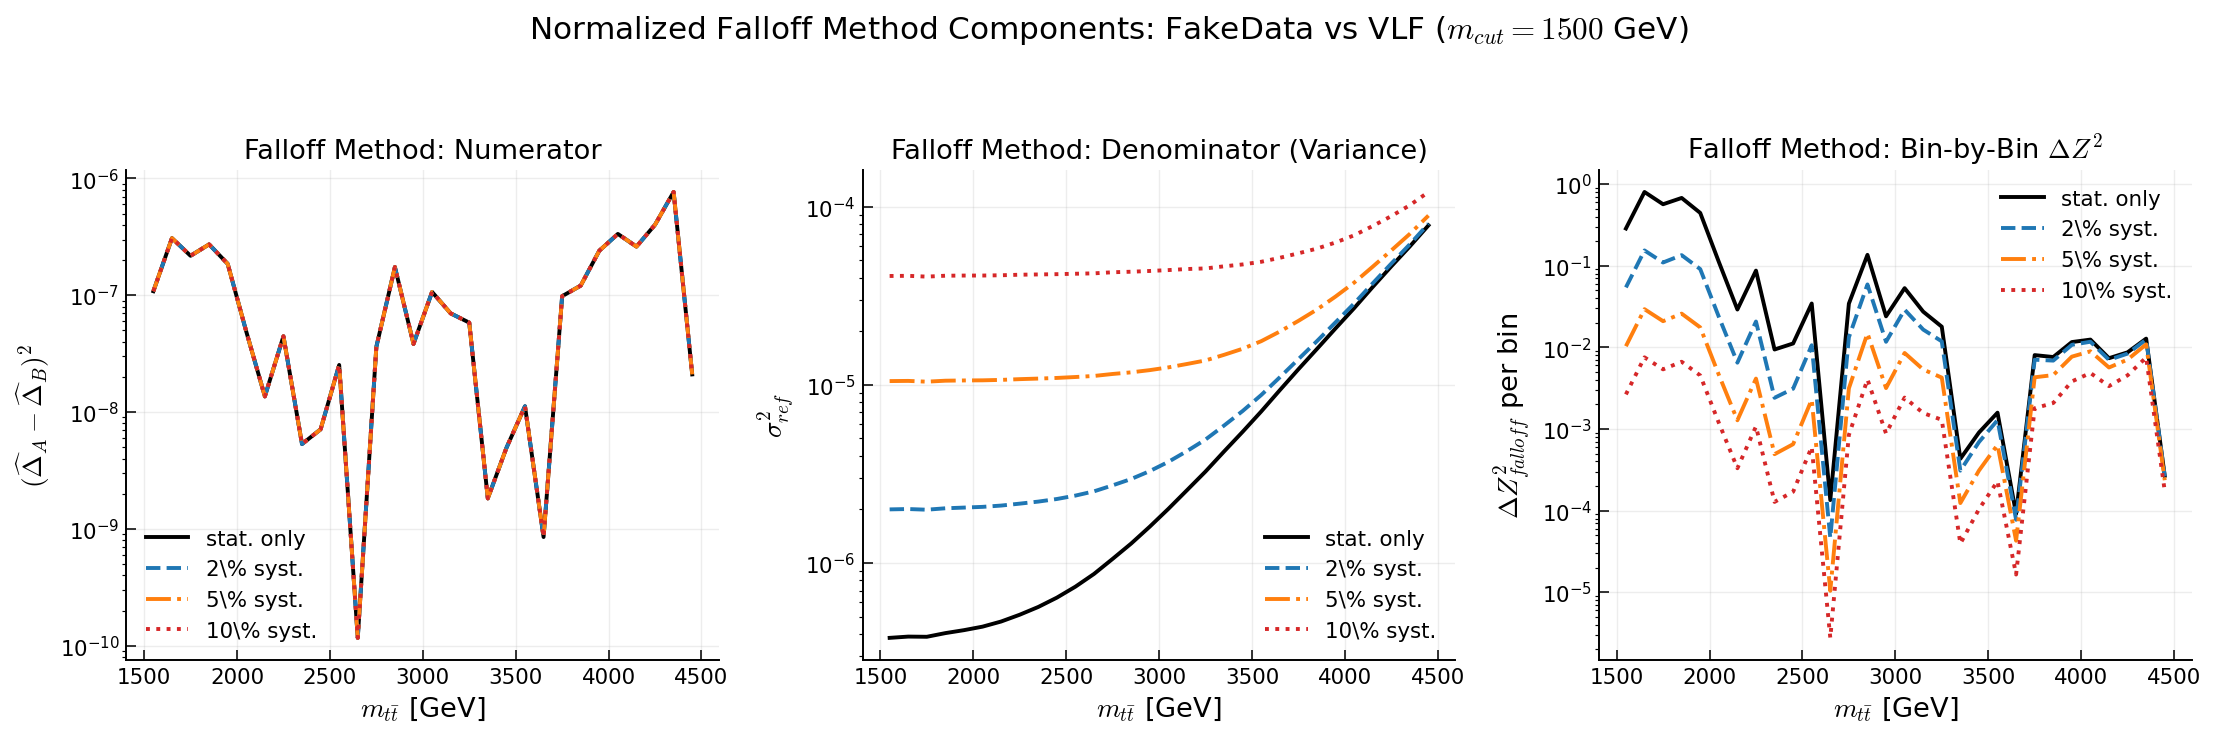

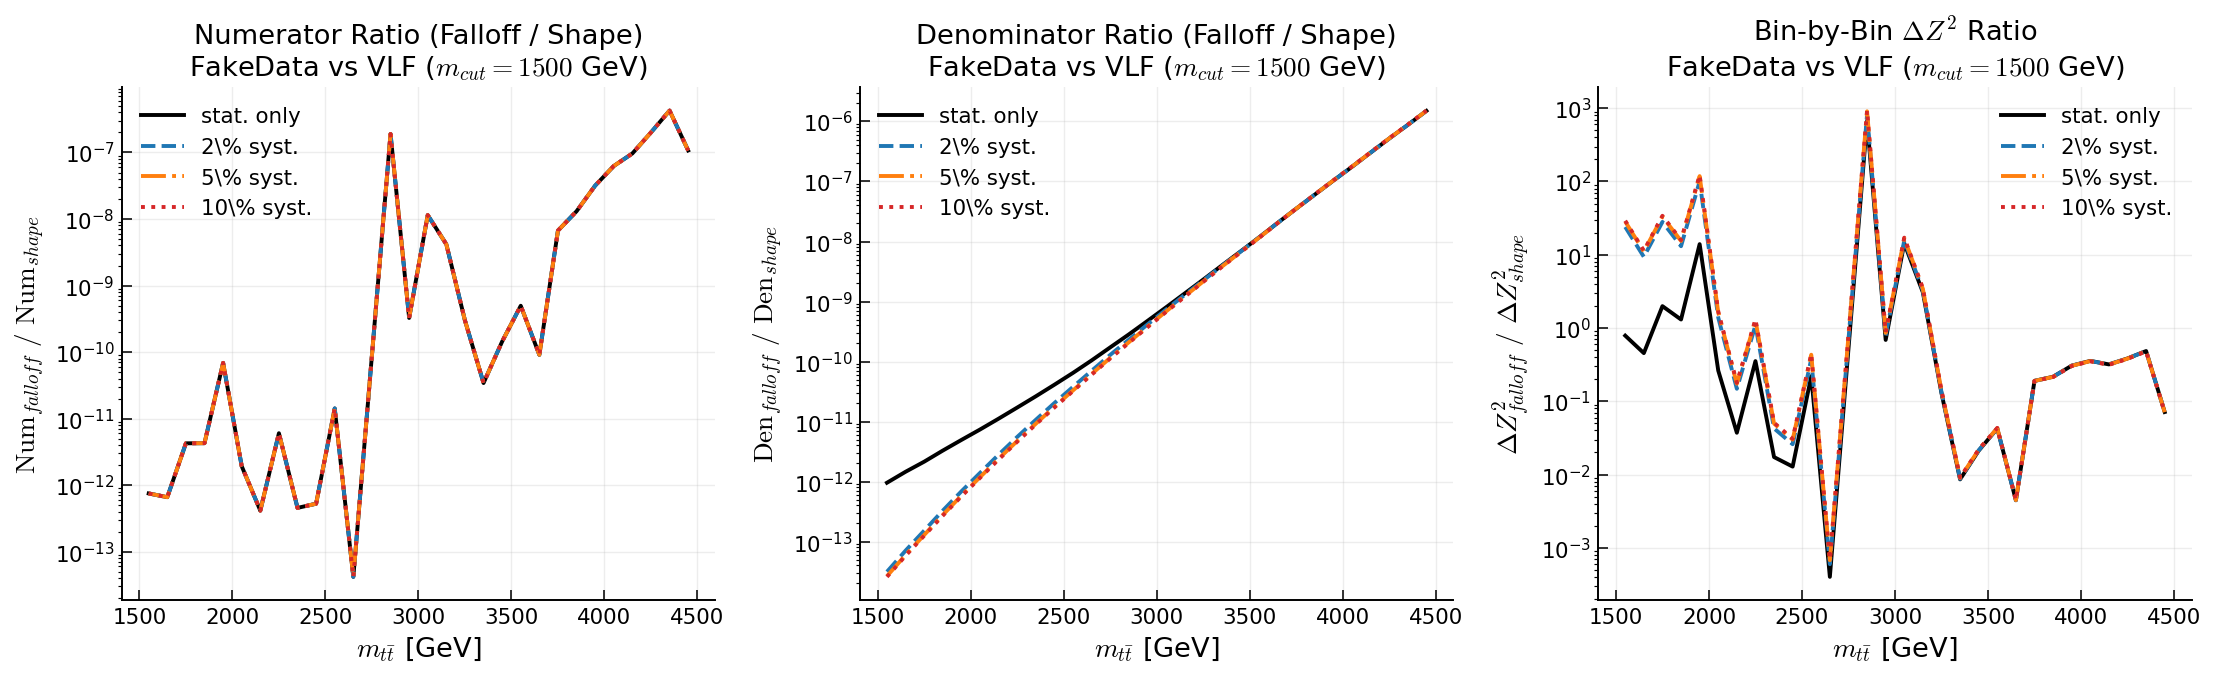

Data saved for pairs: ['FakeData vs Scalar', 'FakeData vs VLF', 'FakeData vs Zprime']


In [14]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
labels = ["FakeData", "Scalar", "VLF", "Zprime"]
var = "m_tt"

target_mcut = 1500
target_pair = 'FakeData vs VLF'

mcuts = [500, 1000, 1500, 1800, 2000, 2200, 2500, 3000]
bin_width = 100.0 # GeV
mcut_max = 4_500 # GeV
alpha = 1e-12
L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# Define styles for the plots )
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}

# ------------------------------------------------------------
#  Data Preparation & Main Loop
# ------------------------------------------------------------
df_sm_work = df_sm[[var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_sm_work = df_sm_work[df_sm_work[var] > 0]

df_hyp_work = df_bsm[["label", var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_work = df_hyp_work[df_hyp_work[var] > 0]

global_max = max(df_sm_work[var].max(), df_hyp_work[var].max())

component_store = {}

for mcut in mcuts:
    bin_edge_max = mcut_max if mcut_max is not None else global_max
    sm_mask = (df_sm_work[var] > mcut) & (df_sm_work[var] <= bin_edge_max)
    hyp_mask = (df_hyp_work[var] > mcut) & (df_hyp_work[var] <= bin_edge_max)

    df_sm_tail = df_sm_work[sm_mask].copy()
    df_hyp_tail = df_hyp_work[hyp_mask].copy()

    if len(df_sm_tail) == 0 or len(df_hyp_tail) == 0: continue

    bins = np.arange(mcut, bin_edge_max + bin_width, bin_width)

    h_sm_raw = hp.weighted_hist(df_sm_tail[var].values, df_sm_tail["weight"].values, bins)
    n_sm = h_sm_raw * L_target * 1000.0

    raw_templates = {}
    norm_templates = {}

    ok = True
    for lab in labels:
        sub = df_hyp_tail[df_hyp_tail["label"] == lab]
        if len(sub) == 0:
            ok = False
            break
        h_raw = hp.weighted_hist(sub[var].values, sub["weight"].values, bins)
        raw_templates[lab] = h_raw

    if not ok: continue

    # Cross-section alignment: Explicitly scale BSM templates to the FakeData yield
    ref_template = raw_templates['FakeData'].copy()

    for lab in raw_templates:
        # Scale to match Fake Data, then add SM
        raw_templates[lab] = hp.event_number_normalization(ref_template, raw_templates[lab], lum=L_target) + n_sm
        delta = hp.build_signed_delta(raw_templates[lab], n_sm, alpha=alpha)
        dnorm = hp.normalize_signed_template(delta, alpha=alpha)
        if dnorm is None:
            ok = False
            break
        norm_templates[lab] = dnorm

    if not ok: continue

    # NEW LOOP: Explicitly compare FakeData (A) against all other models (B)
    for lab in labels:
        if lab == 'FakeData':
            continue # Skip comparing FakeData to itself

        a, b = 'FakeData', lab
        dA, dB = norm_templates[a], norm_templates[b]
        hA, hB = raw_templates[a], raw_templates[b]
        pair_name = f"{a} vs {b}"

        for eps in eps_values:
            Z_fa, num_fa, den_fa = hp.asimov_signed_Z_rigorous(dA, dB, hA, hB, n_sm, eps,mode = "test", alpha = alpha)
            _, num_sh, den_sh = hp.asimov_shape_Z_with_syst(hA, hB, frac_syst=eps, mode="test", eps=alpha)

            # Store the underlying mathematical components for the target pair
            if mcut not in component_store: component_store[mcut] = {}
            if pair_name not in component_store[mcut]: component_store[mcut][pair_name] = {}

            component_store[mcut][pair_name][eps] = {
                "num_fa": num_fa, "den_fa": den_fa,
                "num_sh": num_sh, "den_sh": den_sh,
                "bins": bins
            }

# ------------------------------------------------------------
# Plotting Functions
# ------------------------------------------------------------
if target_mcut not in component_store or target_pair not in component_store[target_mcut]:
    print(f"Data not available for {target_pair} at {target_mcut} GeV.")
else:
    # ------------------------------------------------------------
    # PLOT A: Standard Shape Method Components
    # ------------------------------------------------------------
    fig_sh, axes_sh = plt.subplots(1, 3, figsize=(16, 5))

    for eps_syst in eps_values:
        if eps_syst not in component_store[target_mcut][target_pair]: continue
        comp = component_store[target_mcut][target_pair][eps_syst]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        color, ls = syst_styles.get(eps_syst, ("black", "-"))
        label = "stat. only" if eps_syst == 0.0 else rf"{int(100*eps_syst)}\% syst."

        with np.errstate(divide='ignore', invalid='ignore'):
            z2_sh = np.nan_to_num(comp["num_sh"] / comp["den_sh"], posinf=0, neginf=0)

        axes_sh[0].plot(centers, comp["num_sh"], color=color, linestyle=ls, linewidth=2, label=label)
        axes_sh[1].plot(centers, comp["den_sh"], color=color, linestyle=ls, linewidth=2, label=label)
        axes_sh[2].plot(centers, z2_sh, color=color, linestyle=ls, linewidth=2, label=label)

    axes_sh[0].set_title("Standard Shape: Numerator")
    axes_sh[0].set_ylabel(r"$(n_A - n_B)^2$")
    axes_sh[0].set_yscale('log')

    axes_sh[1].set_title("Standard Shape: Denominator (Variance)")
    axes_sh[1].set_ylabel(r"$\sigma^2$")
    axes_sh[1].set_yscale('log')

    axes_sh[2].set_title(r"Standard Shape: Bin-by-Bin $\Delta Z^2$")
    axes_sh[2].set_ylabel(r"$\Delta Z^2_{shape}$ per bin")
    axes_sh[2].set_yscale('log')

    for ax in axes_sh:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
        hp.beautify_axis(ax, grid=True)
        ax.legend(loc="best")

    fig_sh.suptitle(f"Standard Shape Method Components: {target_pair} ($m_{{cut}} = {target_mcut}$ GeV)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig('components_standard_shape.pdf', bbox_inches='tight')
    plt.show()

    # ------------------------------------------------------------
    # PLOT B: Normalized Falloff Method Components
    # ------------------------------------------------------------
    fig_fa, axes_fa = plt.subplots(1, 3, figsize=(16, 5))

    for eps_syst in eps_values:
        if eps_syst not in component_store[target_mcut][target_pair]: continue
        comp = component_store[target_mcut][target_pair][eps_syst]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        color, ls = syst_styles.get(eps_syst, ("black", "-"))
        label = "stat. only" if eps_syst == 0.0 else rf"{int(100*eps_syst)}\% syst."

        with np.errstate(divide='ignore', invalid='ignore'):
            z2_fa = np.nan_to_num(comp["num_fa"] / comp["den_fa"], posinf=0, neginf=0)

        axes_fa[0].plot(centers, comp["num_fa"], color=color, linestyle=ls, linewidth=2, label=label)
        axes_fa[1].plot(centers, comp["den_fa"], color=color, linestyle=ls, linewidth=2, label=label)
        axes_fa[2].plot(centers, z2_fa, color=color, linestyle=ls, linewidth=2, label=label)

    axes_fa[0].set_title("Falloff Method: Numerator")
    axes_fa[0].set_ylabel(r"$(\widehat{\Delta}_A - \widehat{\Delta}_B)^2$")
    axes_fa[0].set_yscale('log')

    axes_fa[1].set_title("Falloff Method: Denominator (Variance)")
    axes_fa[1].set_ylabel(r"$\sigma_{ref}^2$")
    axes_fa[1].set_yscale('log')

    axes_fa[2].set_title(r"Falloff Method: Bin-by-Bin $\Delta Z^2$")
    axes_fa[2].set_ylabel(r"$\Delta Z^2_{falloff}$ per bin")
    axes_fa[2].set_yscale('log')

    for ax in axes_fa:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
        hp.beautify_axis(ax, grid=True)
        ax.legend(loc="best")

    fig_fa.suptitle(f"Normalized Falloff Method Components: {target_pair} ($m_{{cut}} = {target_mcut}$ GeV)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig('components_falloff.pdf', bbox_inches='tight')
    plt.show()

    # ------------------------------------------------------------
    # PLOT C: 3-Panel Diagnostic Ratio Viewer (Falloff / Shape)
    # ------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for eps_syst in eps_values:
        if eps_syst not in component_store[target_mcut][target_pair]: continue

        comp = component_store[target_mcut][target_pair][eps_syst]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        color, ls = syst_styles.get(eps_syst, ("black", "-"))
        label = "stat. only" if eps_syst == 0.0 else rf"{int(100*eps_syst)}\% syst."

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_num = np.nan_to_num(comp["num_fa"] / comp["num_sh"], posinf=0, neginf=0)
            ratio_den = np.nan_to_num(comp["den_fa"] / comp["den_sh"], posinf=0, neginf=0)
            ratio_z2  = np.nan_to_num((comp["num_fa"] / comp["den_fa"]) / (comp["num_sh"] / comp["den_sh"]), posinf=0, neginf=0)

        axes[0].plot(centers, ratio_num, color=color, linestyle=ls, linewidth=2, label=label)
        axes[1].plot(centers, ratio_den, color=color, linestyle=ls, linewidth=2, label=label)
        axes[2].plot(centers, ratio_z2, color=color, linestyle=ls, linewidth=2, label=label)

    axes[0].set_title(rf"Numerator Ratio (Falloff / Shape)" + f"\n{target_pair} ($m_{{cut}} = {target_mcut}$ GeV)")
    axes[0].set_ylabel(r"$ \text{Num}_{falloff} \ / \ \text{Num}_{shape}$")
    axes[0].set_yscale('log')
    hp.beautify_axis(axes[0], grid=True)
    axes[0].legend()

    axes[1].set_title(rf"Denominator Ratio (Falloff / Shape)" + f"\n{target_pair} ($m_{{cut}} = {target_mcut}$ GeV)")
    axes[1].set_ylabel(r"$ \text{Den}_{falloff} \ / \ \text{Den}_{shape}$")
    axes[1].set_yscale('log')
    hp.beautify_axis(axes[1], grid=True)
    axes[1].legend()

    axes[2].set_title(rf"Bin-by-Bin $\Delta Z^2$ Ratio" + f"\n{target_pair} ($m_{{cut}} = {target_mcut}$ GeV)")
    axes[2].set_ylabel(r"$ \Delta Z^2_{falloff} \ / \ \Delta Z^2_{shape} $")
    axes[2].set_yscale('log')
    hp.beautify_axis(axes[2], grid=True)
    axes[2].legend()

    for ax in axes:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")

    plt.tight_layout()
    plt.savefig('diagnostic_plot_ratio.pdf')
    plt.show()

    # ------------------------------------------------------------
    # Final Data Export
    # ------------------------------------------------------------
    shape_falloff_data = {}

    for current_pair in component_store[target_mcut].keys():
        shape_falloff_data[current_pair] = {}

        for eps_syst in eps_values:
            if eps_syst not in component_store[target_mcut][current_pair]: continue

            comp = component_store[target_mcut][current_pair][eps_syst]
            b = comp["bins"]
            centers = 0.5 * (b[:-1] + b[1:])

            with np.errstate(divide='ignore', invalid='ignore'):
                z2_sh = np.nan_to_num(comp["num_sh"] / comp["den_sh"], posinf=0, neginf=0)
                z2_fa = np.nan_to_num(comp["num_fa"] / comp["den_fa"], posinf=0, neginf=0)

            shape_falloff_data[current_pair][eps_syst] = {
                'shape': {
                    'top': comp["num_sh"],
                    'bot': comp["den_sh"],
                    'z2': z2_sh
                },
                'falloff': {
                    'top': comp["num_fa"],
                    'bot': comp["den_fa"],
                    'z2': z2_fa
                }
            }

    shape_falloff_x_centers = centers
    print(f"Data saved for pairs: {list(shape_falloff_data.keys())}")